In [353]:
import numpy as np
import scipy.io as sio
import vtk
from scipy.interpolate import interp1d
from vtk.util.numpy_support import numpy_to_vtk

import os
import cv2
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..", "Code")))
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import pandas as pd
from scripts.visualization.utils.renderizer import EGMRenderer_EGM


In [354]:
algorithm_ID="OMAMI_VAE_Optuna_1"
algorithm_ID_tik_filt="OMAMI_VAE_Optuna_1"
algorithm_ID_tik_no_filt="OMAMI_no_filt"

output_path="/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/"

csv_dl=f"/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/{algorithm_ID}/metrics_dl.csv"
df_dl = pd.read_csv(csv_dl)
df_dl = df_dl.sort_values(by='Correlation', ascending=False)
df_dl.columns = df_dl.columns.str.replace('_', '', regex=True)  # Elimina los guiones bajos


csv_tik_filt=f"/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/{algorithm_ID_tik_filt}/metrics_tik.csv"
df_tik_filt = pd.read_csv(csv_tik_filt)
df_tik_filt.columns = df_tik_filt.columns.str.replace('_', '', regex=True)  # Elimina los guiones bajos



csv_tik_no_filt=f"/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/{algorithm_ID_tik_no_filt}/metrics_tik.csv"
df_tik_no_filt = pd.read_csv(csv_tik_no_filt)
df_tik_no_filt.columns = df_tik_no_filt.columns.str.replace('_', '', regex=True)  # Elimina los guiones bajos
# Si prefieres reemplazarlos por espacios:
# df.columns = df.columns.str.replace('_', ' ', regex=True)


#df_dl.rename(columns={'name': 'name', 'mean correlation': 'MeanCorr DL', 'mean RMSE': 'MeanRMSE DL'}, inplace=True)
df_DL=np.round(df_dl, 3)
df_dl.head(20)



,name,Correlation,RMSE,PeakdetectorRecall,PeakdetectorPrecision,PeakdetectorError,DTW,Coherence
2,Simulation_01_200212_001_ 5,0.613163,0.463047,0.310980,0.886097,0.449390,123.191188,0.799085
4,Simulation_01_200316_001_ 3,0.605051,0.467132,0.302344,0.885589,0.423318,123.766801,0.834312
5,Simulation_01_200316_001_ 4,0.120840,0.572747,0.428821,0.493186,0.501229,225.029045,0.217621
9,Simulation_01_200428_001_010,0.116488,0.570314,0.442874,0.509227,0.519929,217.299153,0.212749
7,Simulation_01_200428_001_004,0.068573,0.580690,0.460524,0.505574,0.552636,223.491053,0.219641
8,Simulation_01_200428_001_008,0.044184,0.603139,0.500098,0.510566,0.483672,219.145437,0.216164
10,Simulation_01_210119_001_001,0.023710,0.557280,0.276243,0.550426,0.548181,59.855917,1.000000
3,Simulation_01_200212_001_ 10,0.021692,0.604317,0.438702,0.480148,0.556964,240.859948,0.215221
1,LA_RSPV_CAF_150115,0.007589,0.635992,0.576390,0.531855,0.473141,118.366450,0.505981
6,Simulation_01_200316_001_ 8,0.005150,0.594923,0.402856,0.423603,0.618460,232.341385,0.217738


In [355]:
algorithm_list= ['OMAMI_repeated', 'OMAMI_VAE_Optuna_1', 'OMAMI_no_filt', 'OMAMI_VAE_no_filt' ]
algorithm_mod_name = [algo.replace('_', '') for algo in algorithm_list]

merged_df=None
cont=0
for algorithm_ID in algorithm_list:
    algorithm_ID_mod=algorithm_mod_name[cont]
    cont+=1
    # Cargar el archivo CSV
    csv_dl = f"/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/experiments/experiments_VAE/{algorithm_ID}/metrics_dl.csv"
    df = pd.read_csv(csv_dl)
    df.columns = df.columns.str.replace('_', '', regex=True)  # Elimina los guiones bajos
    

    # Agregar sufijo al DataFrame actual
    df = df.add_suffix(f"_{algorithm_ID_mod}")
    df.rename(columns={f'name_{algorithm_ID_mod}': 'name'}, inplace=True)

    # Si `merged_df` no está inicializado, usar el primer DataFrame como base
    if merged_df is None:
        merged_df = df
    else:
        # Fusionar con el DataFrame base
        merged_df = pd.merge(merged_df, df, on='name', how='outer')

merged_df_dl=merged_df.copy()

algorithm_mod_name+=['ZotFilt']
algorithm_mod_name+=['ZotNoFilt']


#Add ZOT results
df = df_tik_filt.add_suffix(f"_ZotFilt")
df_filt = df
df.rename(columns={f'name_ZotFilt': 'name'}, inplace=True)
merged_df = pd.merge(merged_df, df, on='name', how='outer')


df = df_tik_no_filt.add_suffix(f"_ZotNoFilt")
df.rename(columns={f'name_ZotNoFilt': 'name'}, inplace=True)
merged_df = pd.merge(merged_df, df, on='name', how='outer')
df_tik_merged = pd.merge(df_filt, df, on='name', how='outer')


df_tik_merged.head()


,name,Correlation_ZotFilt,RMSE_ZotFilt,PeakdetectorRecall_ZotFilt,PeakdetectorPrecision_ZotFilt,PeakdetectorError_ZotFilt,DTW_ZotFilt,Coherence_ZotFilt,Correlation_ZotNoFilt,RMSE_ZotNoFilt,PeakdetectorRecall_ZotNoFilt,PeakdetectorPrecision_ZotNoFilt,PeakdetectorError_ZotNoFilt,DTW_ZotNoFilt,Coherence_ZotNoFilt
0,LA_PLAW_140711_arm,0.077005,0.546940,0.484757,0.691532,0.509337,113.629493,0.661241,0.099530,0.543128,0.340154,0.570221,0.582607,190.243763,0.489230
1,LA_RSPV_CAF_150115,0.060201,0.583208,0.584737,0.629688,0.467173,108.966838,0.554812,0.061942,0.563192,0.461049,0.578393,0.478621,261.797972,0.212399
2,Simulation_01_200212_001_ 5,0.029997,0.554471,0.180803,0.720672,0.600711,132.138408,0.905860,0.016105,0.648374,0.117389,0.326268,0.739036,163.512005,0.585867
3,Simulation_01_200212_001_ 10,0.043108,0.575081,0.437919,0.623344,0.652061,216.958203,0.282199,0.046684,0.563038,0.335748,0.559721,0.562215,474.358111,0.158008
4,Simulation_01_200316_001_ 3,0.030923,0.533944,0.177243,0.710377,0.587571,127.450310,0.898946,0.034181,0.645523,0.117177,0.315010,0.741841,163.088032,0.582723


In [356]:
merged_df.head(20)

,name,Correlation_OMAMIrepeated,RMSE_OMAMIrepeated,PeakdetectorRecall_OMAMIrepeated,PeakdetectorPrecision_OMAMIrepeated,PeakdetectorError_OMAMIrepeated,DTW_OMAMIrepeated,Coherence_OMAMIrepeated,Correlation_OMAMIVAEOptuna1,RMSE_OMAMIVAEOptuna1,...,PeakdetectorError_ZotFilt,DTW_ZotFilt,Coherence_ZotFilt,Correlation_ZotNoFilt,RMSE_ZotNoFilt,PeakdetectorRecall_ZotNoFilt,PeakdetectorPrecision_ZotNoFilt,PeakdetectorError_ZotNoFilt,DTW_ZotNoFilt,Coherence_ZotNoFilt
0,LA_PLAW_140711_arm,0.026365,0.599248,0.377033,0.383743,0.542778,222.652928,0.327113,0.002061,0.582400,...,0.509337,113.629493,0.661241,0.099530,0.543128,0.340154,0.570221,0.582607,190.243763,0.489230
1,LA_RSPV_CAF_150115,0.006261,0.575233,0.442698,0.332110,0.517835,380.035551,0.150890,0.007589,0.635992,...,0.467173,108.966838,0.554812,0.061942,0.563192,0.461049,0.578393,0.478621,261.797972,0.212399
2,Simulation_01_200212_001_ 5,0.650290,0.475434,0.293163,0.853856,0.494584,222.404727,0.595684,0.613163,0.463047,...,0.600711,132.138408,0.905860,0.016105,0.648374,0.117389,0.326268,0.739036,163.512005,0.585867
3,Simulation_01_200212_001_ 10,0.040717,0.587912,0.347514,0.364322,0.519500,520.469808,0.106488,0.021692,0.604317,...,0.652061,216.958203,0.282199,0.046684,0.563038,0.335748,0.559721,0.562215,474.358111,0.158008
4,Simulation_01_200316_001_ 3,0.649851,0.477678,0.283443,0.852641,0.456898,225.096437,0.595278,0.605051,0.467132,...,0.587571,127.450310,0.898946,0.034181,0.645523,0.117177,0.315010,0.741841,163.088032,0.582723
5,Simulation_01_200316_001_ 4,0.218968,0.550739,0.360613,0.407846,0.564138,495.926404,0.114212,0.120840,0.572747,...,0.497196,193.188388,0.298627,0.083252,0.551032,0.333746,0.522077,0.550723,453.299620,0.161327
6,Simulation_01_200316_001_ 8,0.265425,0.621743,0.312336,0.338472,0.667957,499.332085,0.172630,0.005150,0.594923,...,0.548063,198.838845,0.342384,0.085865,0.558909,0.344610,0.563113,0.543215,466.789368,0.202172
7,Simulation_01_200428_001_004,0.240863,0.599347,0.346866,0.355691,0.557125,514.723405,0.126478,0.068573,0.580690,...,0.482553,198.448331,0.302987,0.090211,0.530151,0.345263,0.557552,0.520998,440.609652,0.172931
8,Simulation_01_200428_001_008,0.205031,0.574364,0.334343,0.361496,0.573320,480.817674,0.122760,0.044184,0.603139,...,0.497598,197.833254,0.296542,0.088632,0.530313,0.340042,0.567332,0.513133,428.137785,0.174387
9,Simulation_01_200428_001_010,0.079154,0.582373,0.289576,0.320659,0.520368,467.422401,0.103635,0.116488,0.570314,...,0.551255,198.968192,0.258883,0.093116,0.514760,0.330864,0.532333,0.512293,412.495147,0.150470


/tmp/ipykernel_563511/2570778274.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)


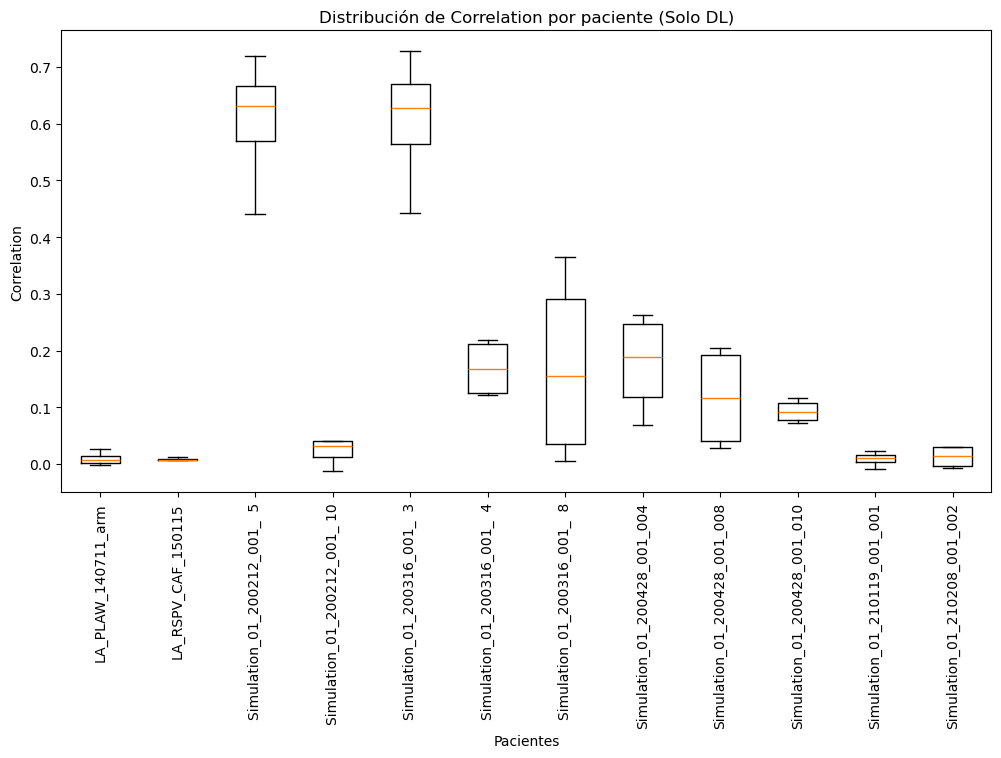

/tmp/ipykernel_563511/2570778274.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)


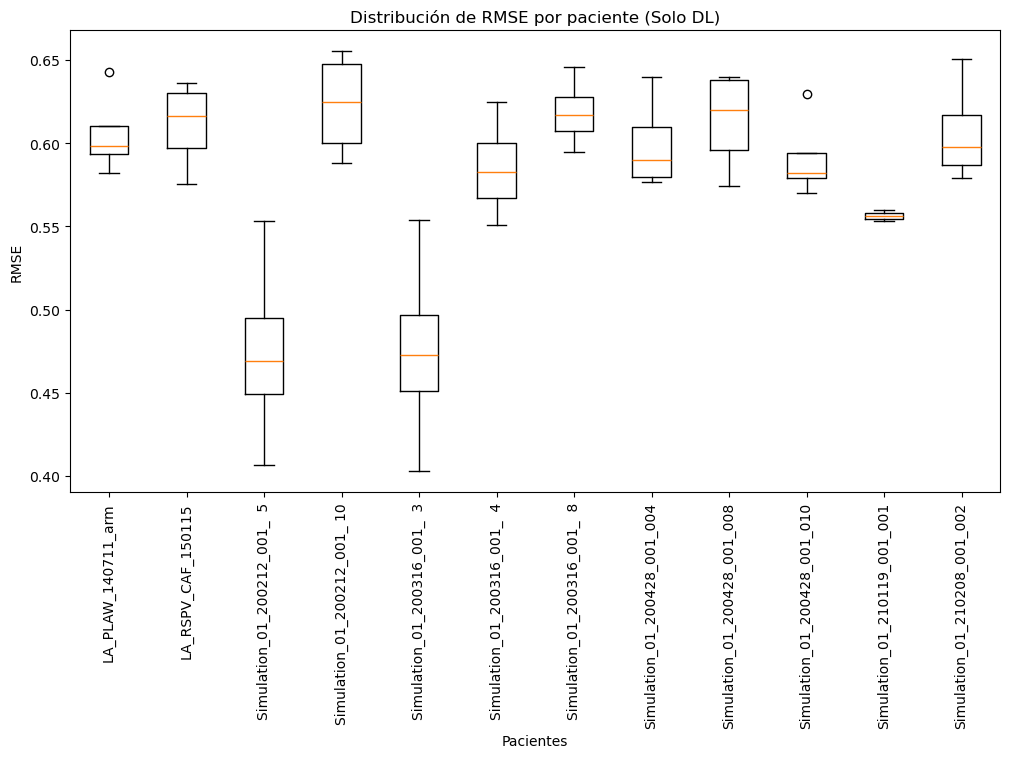

/tmp/ipykernel_563511/2570778274.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)


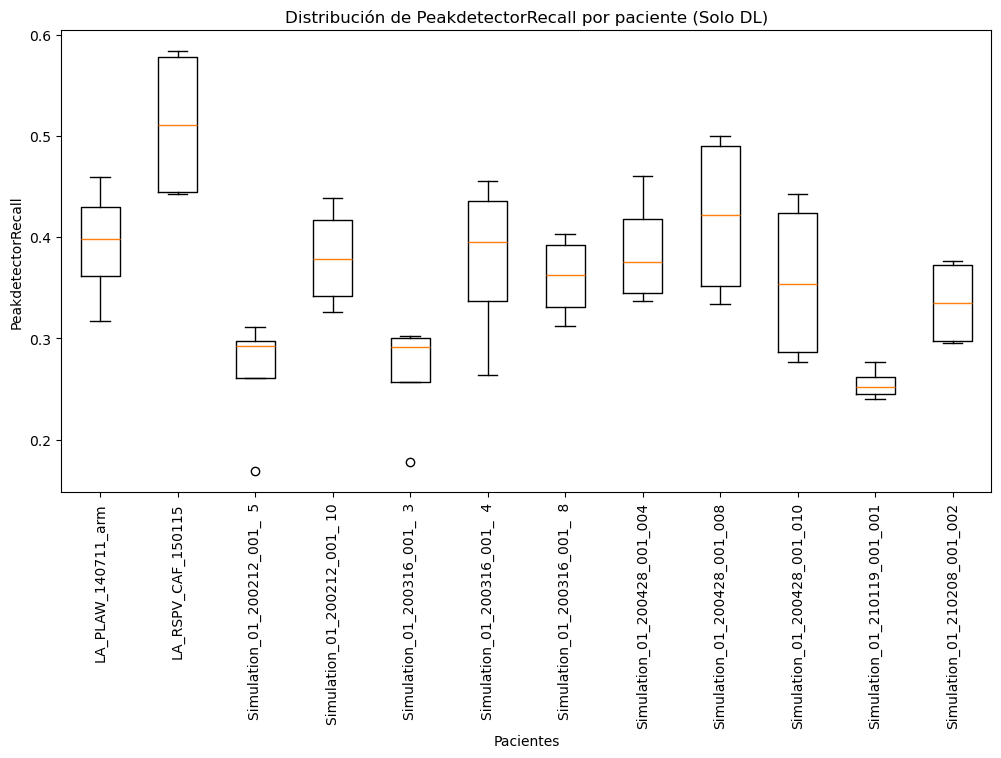

/tmp/ipykernel_563511/2570778274.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)


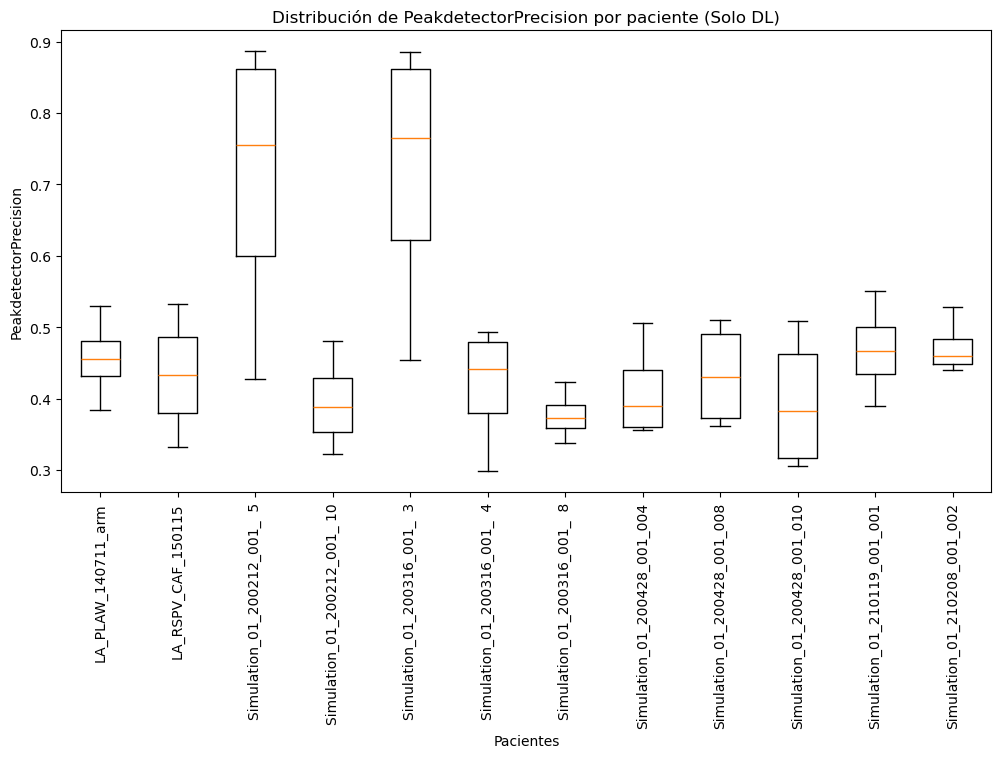

/tmp/ipykernel_563511/2570778274.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)


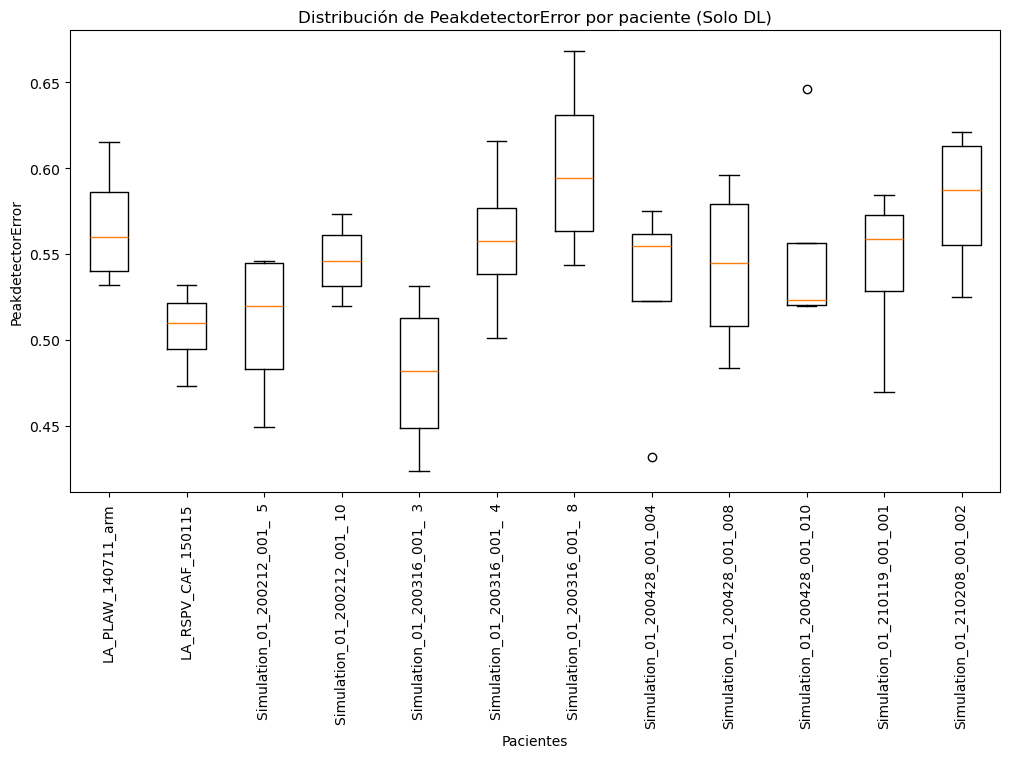

/tmp/ipykernel_563511/2570778274.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)


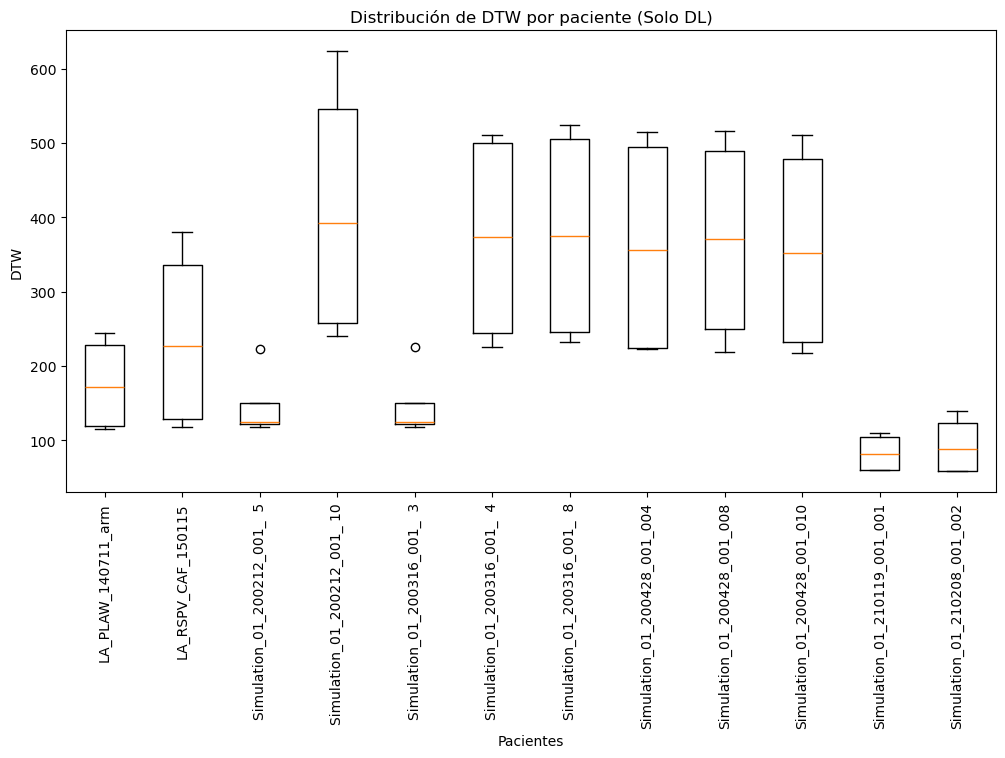

/tmp/ipykernel_563511/2570778274.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)


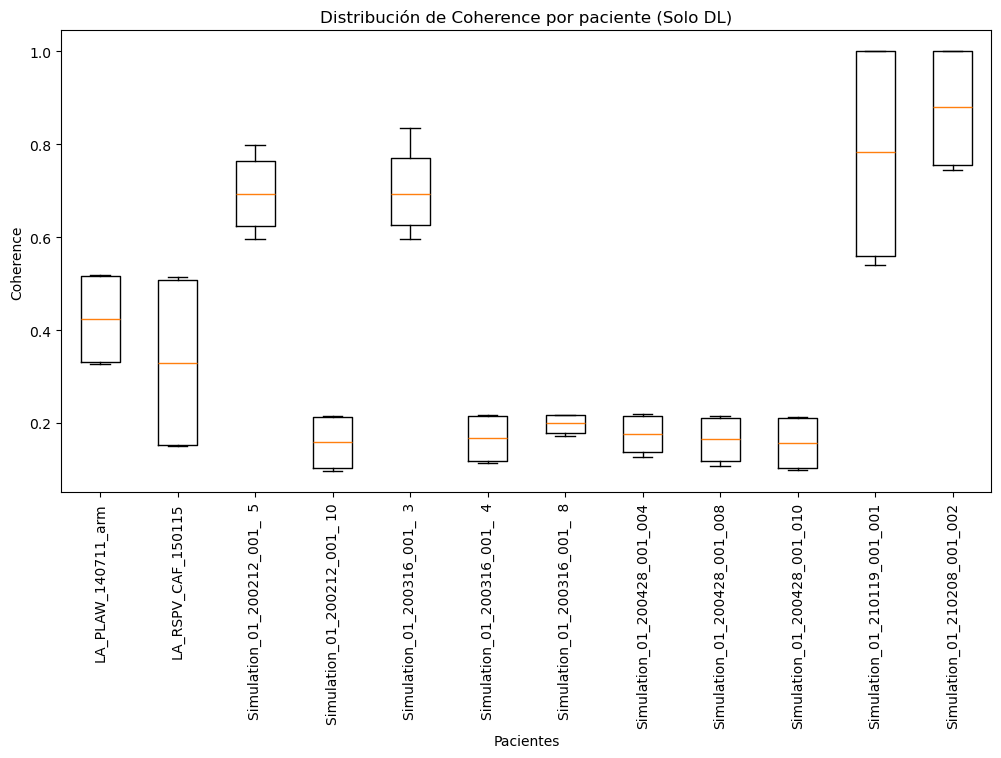

/tmp/ipykernel_563511/2570778274.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)


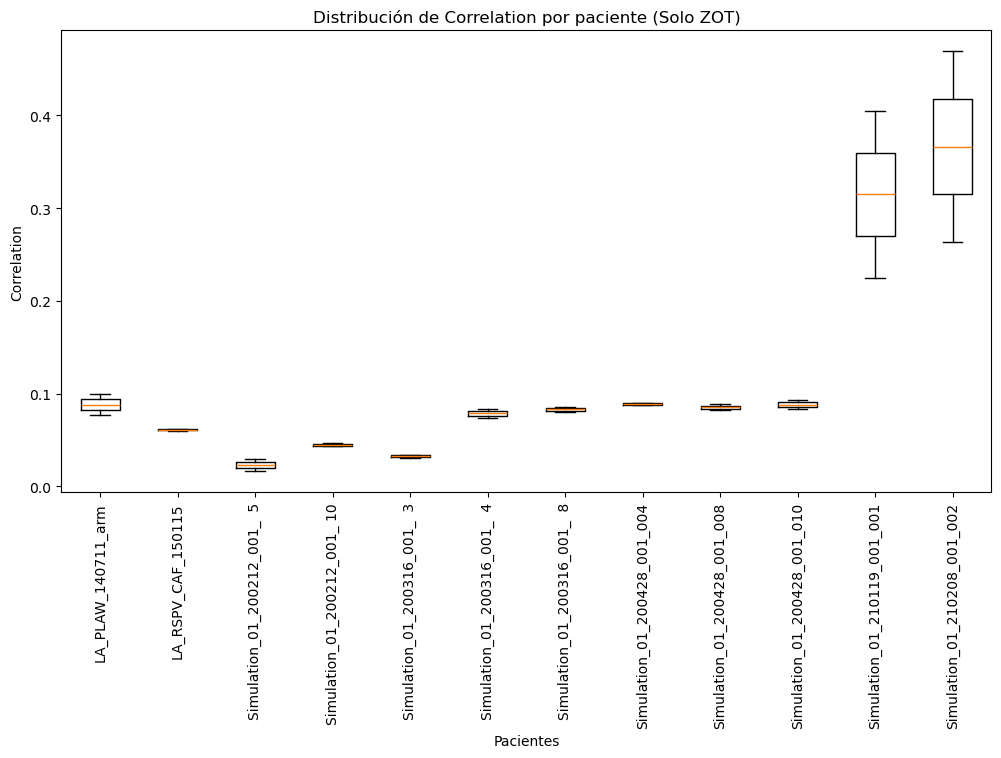

/tmp/ipykernel_563511/2570778274.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)


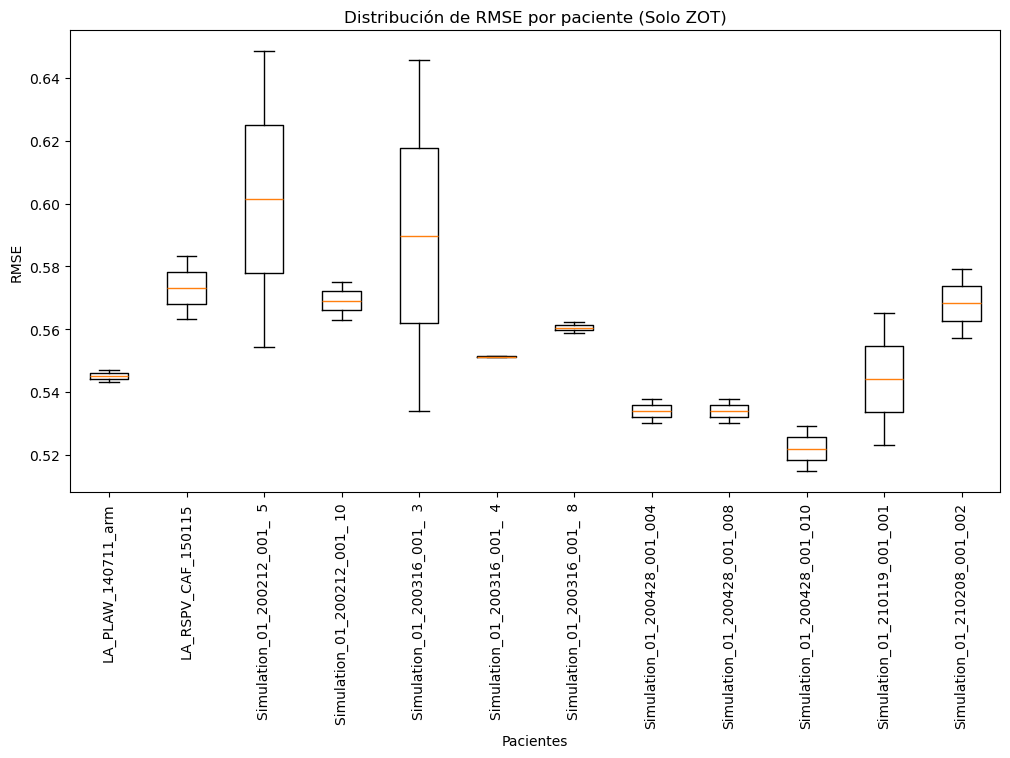

/tmp/ipykernel_563511/2570778274.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)


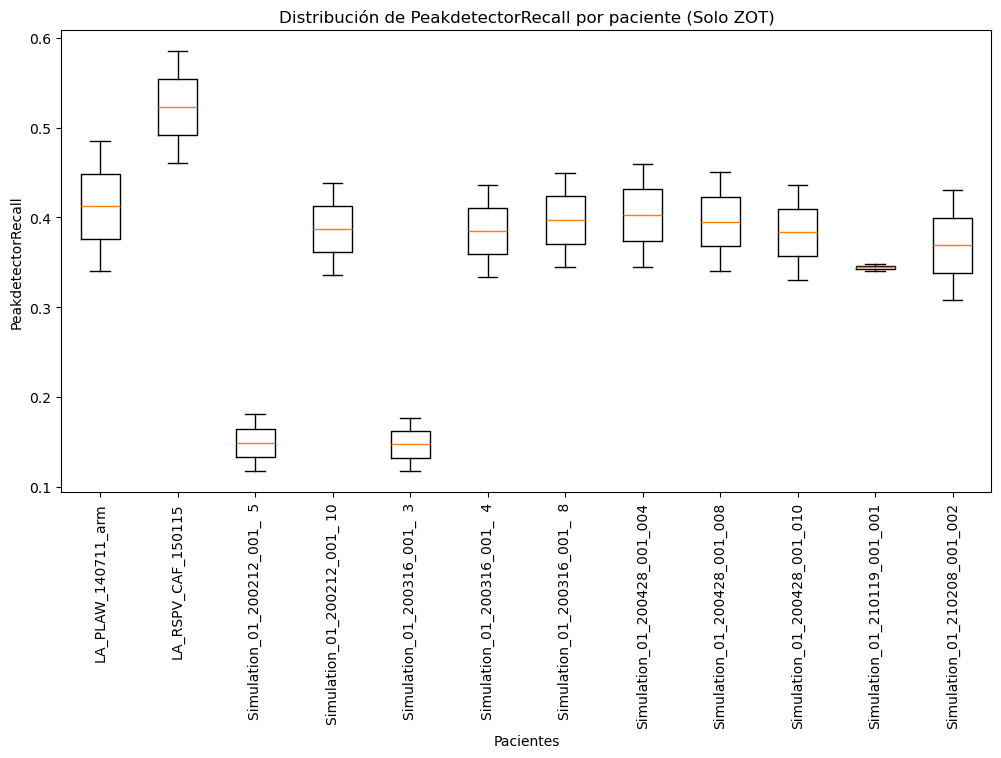

/tmp/ipykernel_563511/2570778274.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)


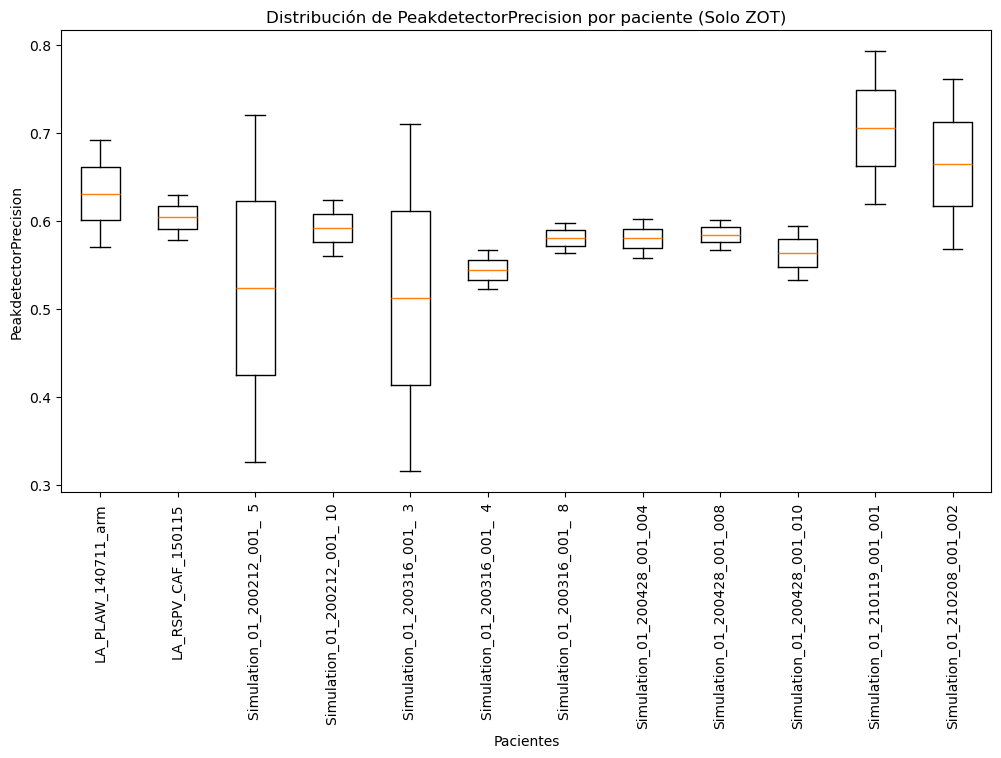

/tmp/ipykernel_563511/2570778274.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)


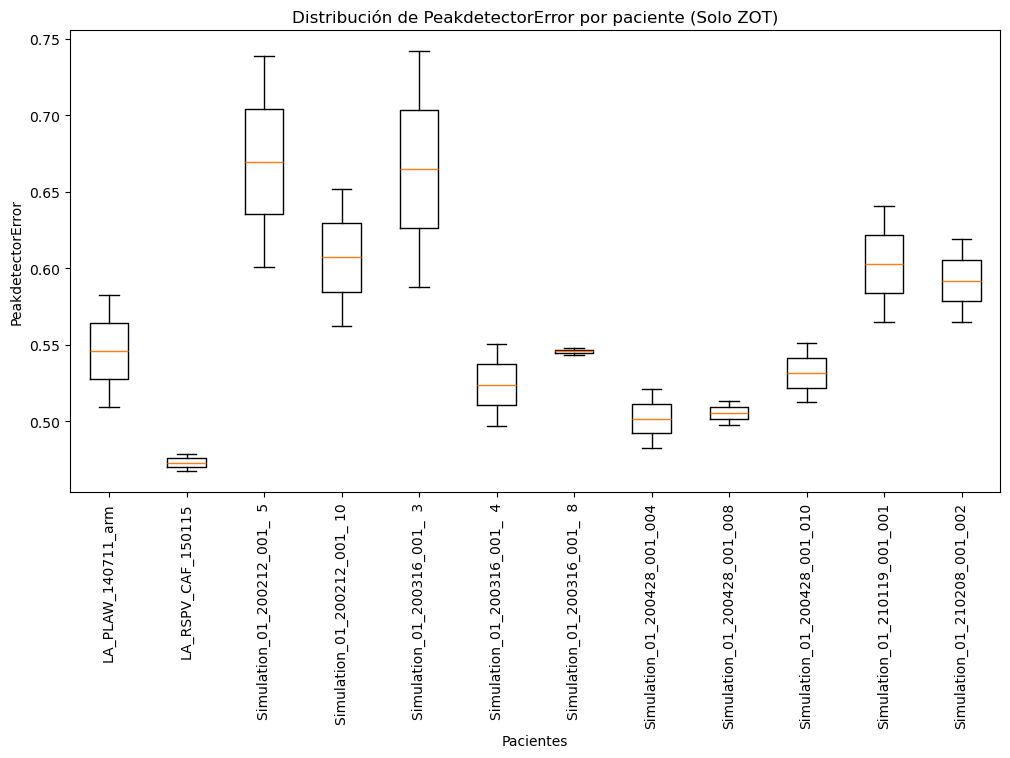

/tmp/ipykernel_563511/2570778274.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)


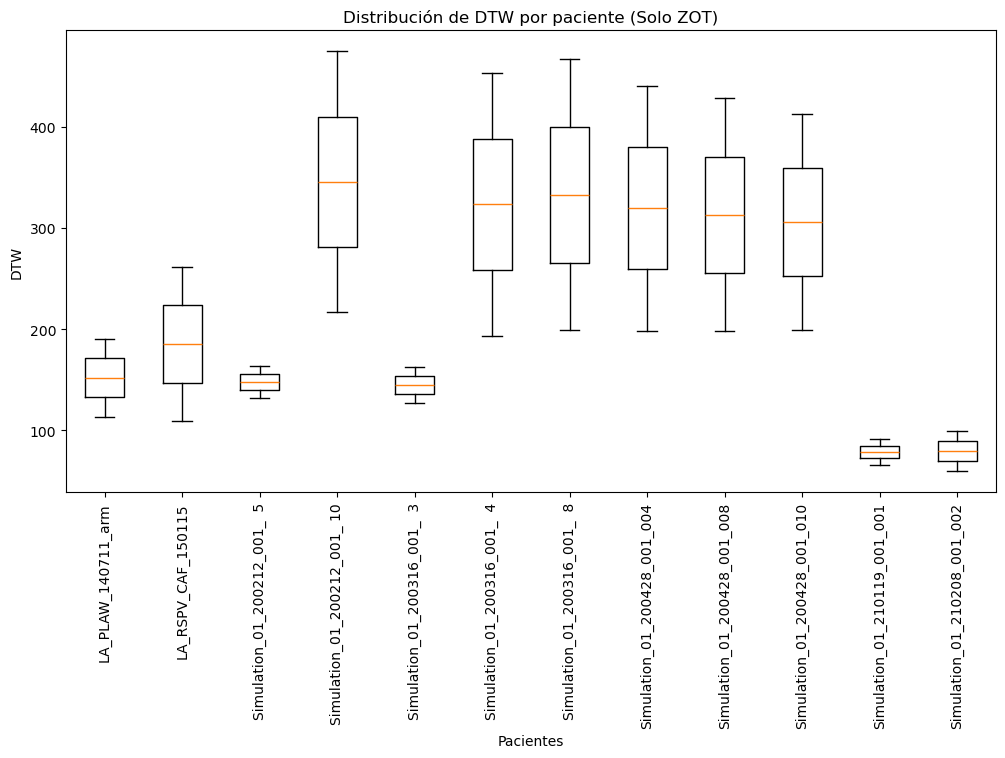

/tmp/ipykernel_563511/2570778274.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)


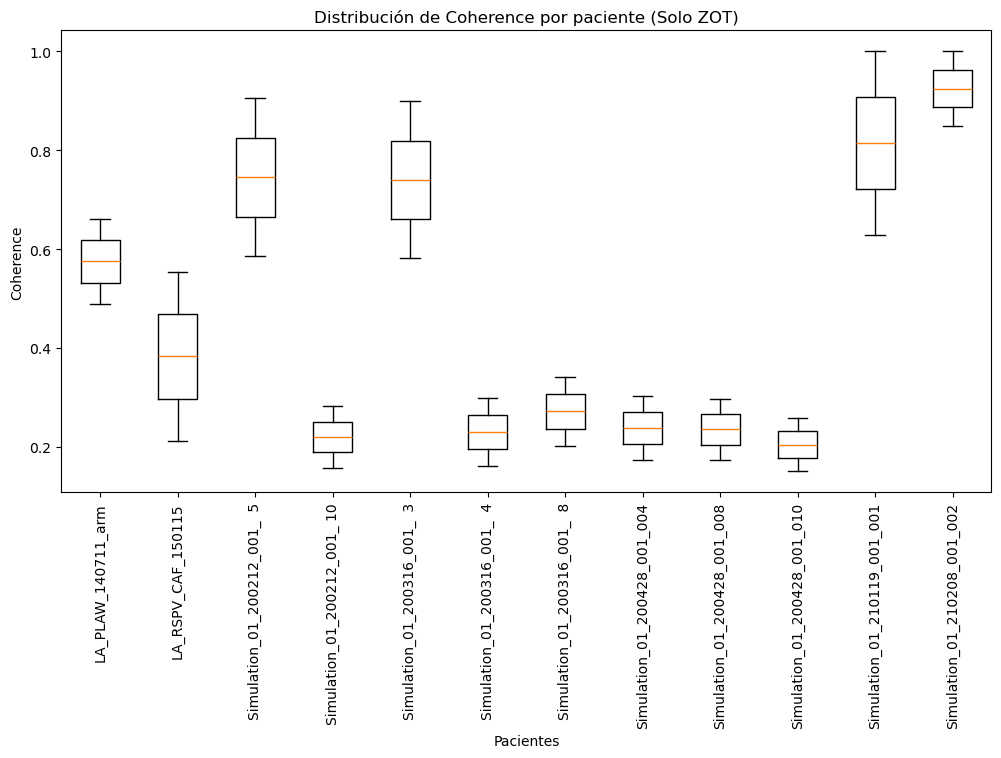

In [357]:
import matplotlib.pyplot as plt

df=merged_df_dl
# 1️⃣ Extraer los nombres de las métricas sin el sufijo del algoritmo
metric_columns = [col for col in df.columns if col != "name"]
metric_dict = {col: col.split("_")[0] for col in metric_columns}  # Extraer solo la métrica

# 2️⃣ Agrupar columnas por métrica
grouped_metrics = {}
for col in metric_columns:
    metric_name = col.split("_")[0]  # Extrae solo la métrica
    if metric_name not in grouped_metrics:
        grouped_metrics[metric_name] = []
    grouped_metrics[metric_name].append(col)

# 3️⃣ Crear un boxplot por cada métrica
for metric, columns in grouped_metrics.items():
    plt.figure(figsize=(12, 6))
    
    # Extraer los datos de la métrica y transponer para que los pacientes sean el eje X
    data_to_plot = df[columns].T  # Transponemos el DataFrame para que los pacientes sean el eje X
    
    # 4️⃣ Graficar el boxplot
    plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)
    
    # Títulos y etiquetas
    plt.title(f"Distribución de {metric} por paciente (Solo DL)")
    plt.xlabel("Pacientes")
    plt.ylabel(metric)
    plt.xticks(rotation=90)  # Rotar nombres de pacientes para mejor visibilidad
    
    # Mostrar la gráfica
    plt.show()


import matplotlib.pyplot as plt

df=df_tik_merged
# 1️⃣ Extraer los nombres de las métricas sin el sufijo del algoritmo
metric_columns = [col for col in df.columns if col != "name"]
metric_dict = {col: col.split("_")[0] for col in metric_columns}  # Extraer solo la métrica

# 2️⃣ Agrupar columnas por métrica
grouped_metrics = {}
for col in metric_columns:
    metric_name = col.split("_")[0]  # Extrae solo la métrica
    if metric_name not in grouped_metrics:
        grouped_metrics[metric_name] = []
    grouped_metrics[metric_name].append(col)

# 3️⃣ Crear un boxplot por cada métrica
for metric, columns in grouped_metrics.items():
    plt.figure(figsize=(12, 6))
    
    # Extraer los datos de la métrica y transponer para que los pacientes sean el eje X
    data_to_plot = df[columns].T  # Transponemos el DataFrame para que los pacientes sean el eje X
    
    # 4️⃣ Graficar el boxplot
    plt.boxplot(data_to_plot.values, labels=df["name"], vert=True)
    
    # Títulos y etiquetas
    plt.title(f"Distribución de {metric} por paciente (Solo ZOT)")
    plt.xlabel("Pacientes")
    plt.ylabel(metric)
    plt.xticks(rotation=90)  # Rotar nombres de pacientes para mejor visibilidad
    
    # Mostrar la gráfica
    plt.show()



In [358]:
 dl_data.head()

,RMSE_OMAMIrepeated,RMSE_OMAMIVAEOptuna1,RMSE_OMAMInofilt,RMSE_OMAMIVAEnofilt
0,0.599248,0.582400,0.642654,0.597155
1,0.575233,0.635992,0.604077,0.628540
2,0.475434,0.463047,0.406587,0.553509
3,0.587912,0.604317,0.644904,0.655209
4,0.477678,0.467132,0.402574,0.553974


In [359]:
 print("len(dl_positions)", len(dl_positions))
print("len(zot_positions)", len(zot_positions))
print("len(dl_data.values)", len(dl_data.values))
print(" len(zot_data.values)",  len(zot_data.values))

len(dl_positions) 12
len(zot_positions) 12
len(dl_data.values) 12
 len(zot_data.values) 12


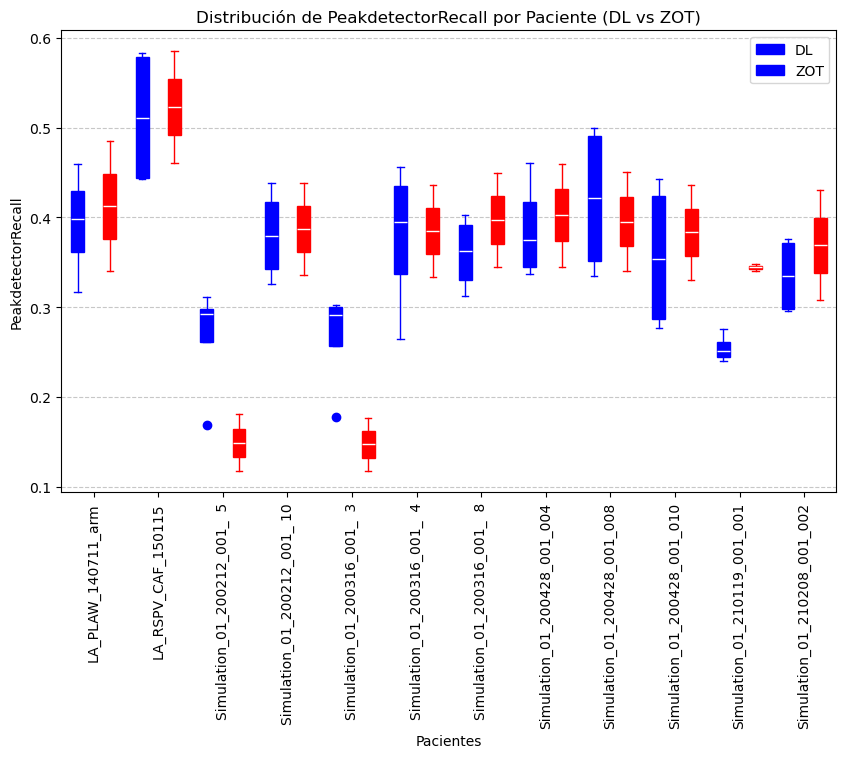

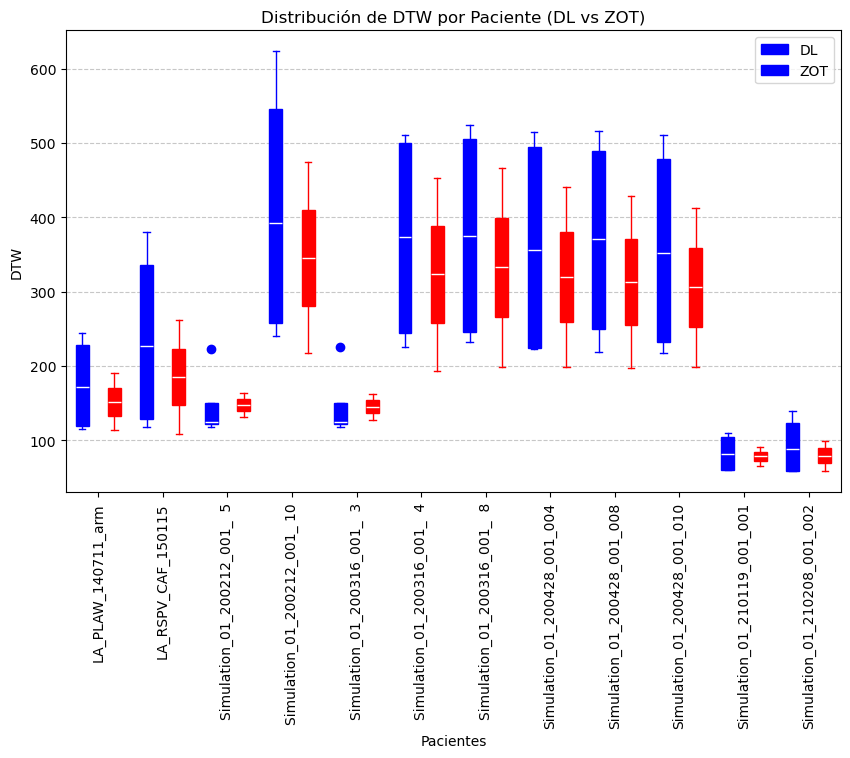

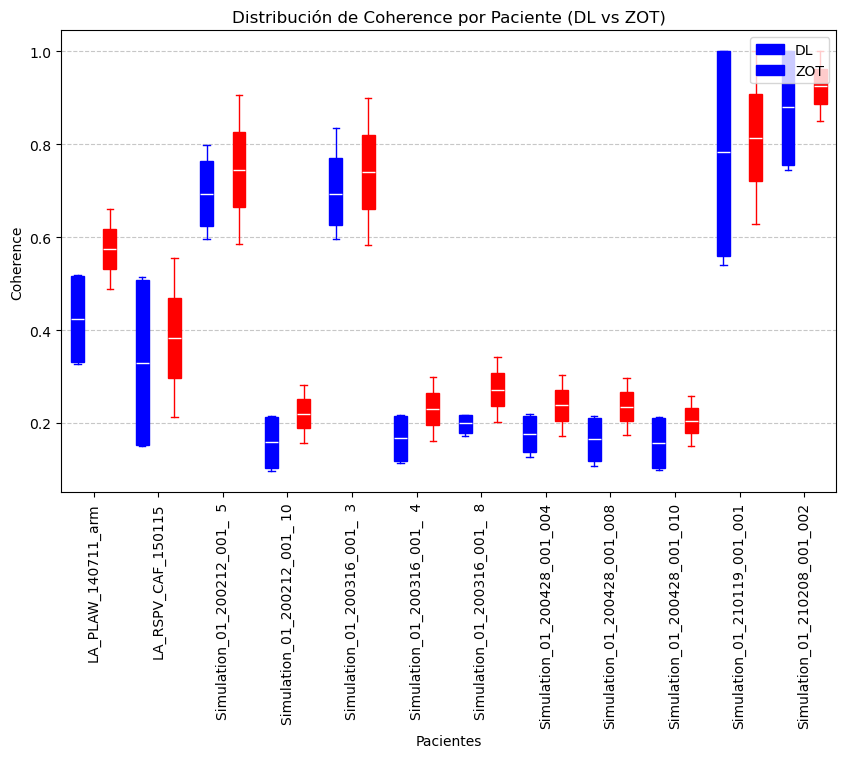

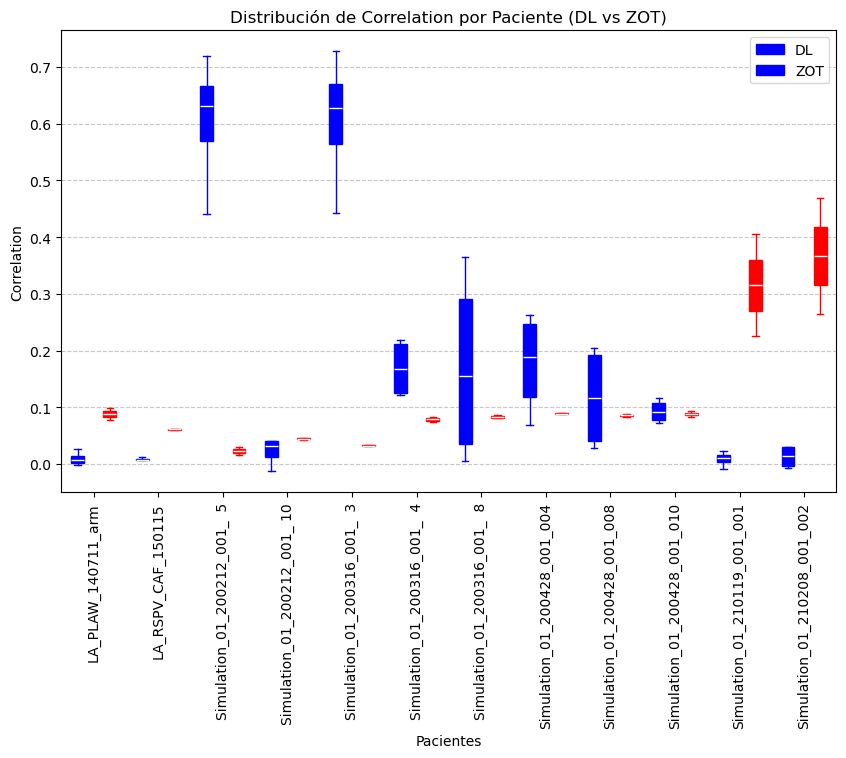

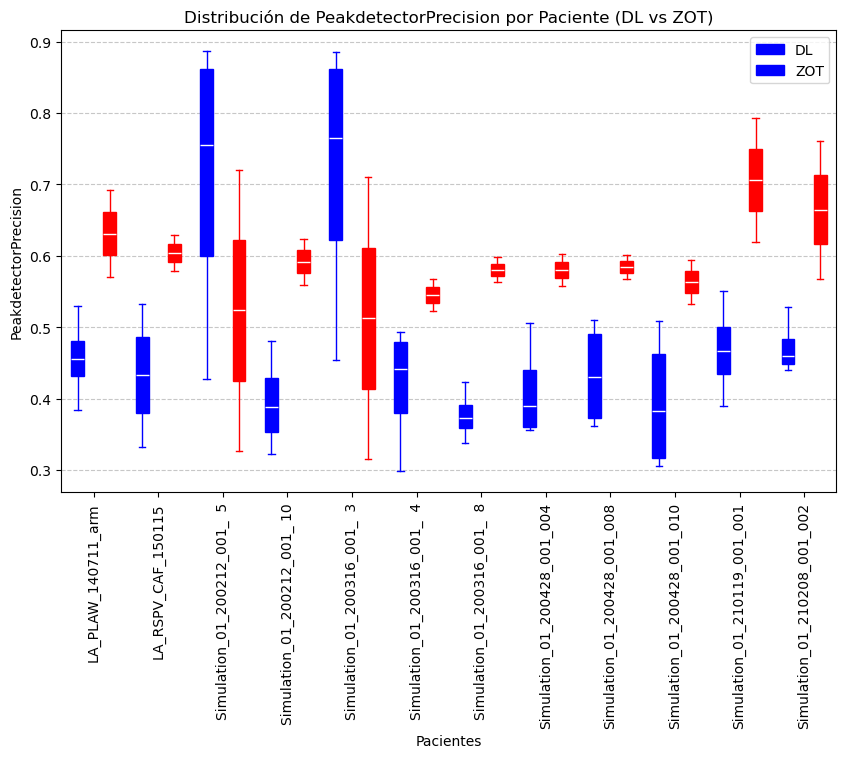

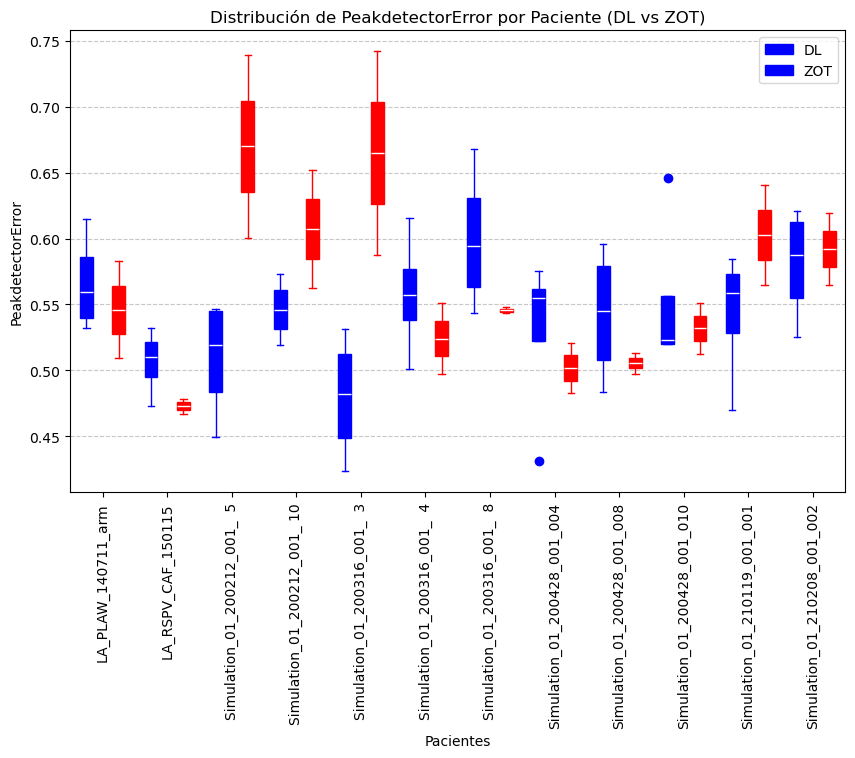

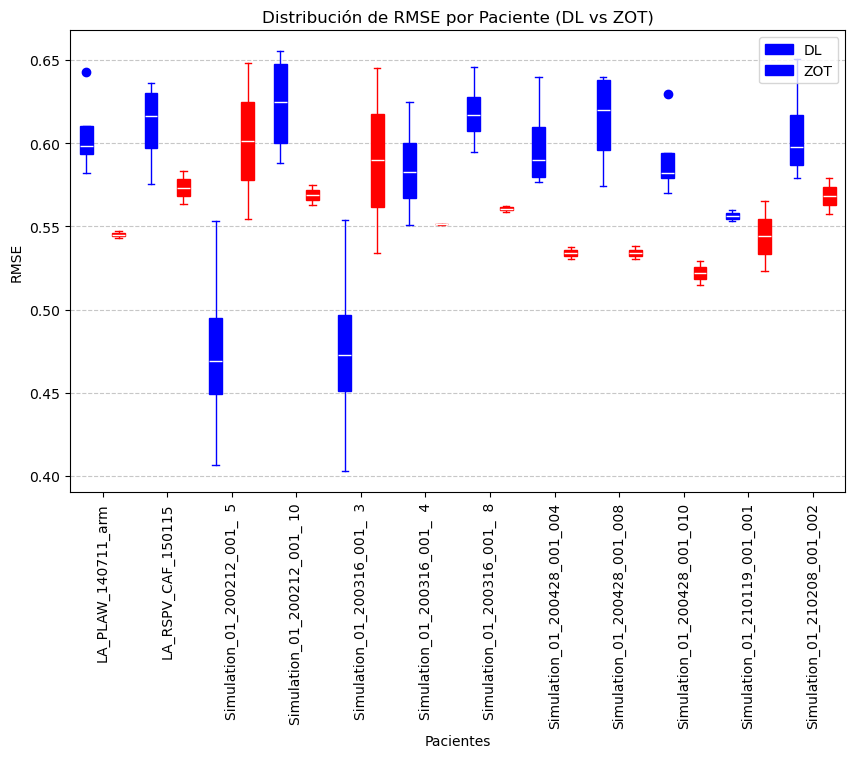

In [360]:
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Iterar sobre cada métrica
for metric in common_metrics:
    if metric not in dl_grouped or metric not in tik_grouped:
        continue  # Ignorar métricas no comunes

    dl_columns = dl_grouped[metric]
    tik_columns = tik_grouped[metric]

    # 📌 Extraer datos por paciente
    dl_data = merged_df_dl[dl_columns]  # Todas las métricas DL para la métrica actual
    zot_data = df_tik_merged[tik_columns]  # Todas las métricas ZOT para la métrica actual

    # 📌 Crear figura
    plt.figure(figsize=(10, 6))

    # 📌 Posiciones de las cajas (pares: DL, impares: ZOT)
    num_pacientes = len(merged_df_dl)
    dl_positions = np.arange(num_pacientes) * 2 + 1  # 1, 3, 5, 7...
    zot_positions = dl_positions + 1  # 2, 4, 6, 8...

    # 📊 Crear boxplots
    bp_dl = plt.boxplot(
        dl_data.values.T,  # Transponer para que cada paciente tenga su caja
        positions=dl_positions,
        widths=0.4,
        patch_artist=True,
        boxprops=dict(facecolor="blue", color="blue"),
        medianprops=dict(color="white"),
        whiskerprops=dict(color="blue"),
        capprops=dict(color="blue"),
        flierprops=dict(markerfacecolor="blue", markeredgecolor="blue"),
    )

    bp_zot = plt.boxplot(
        zot_data.values.T,
        positions=zot_positions,
        widths=0.4,
        patch_artist=True,
        boxprops=dict(facecolor="red", color="red"),
        medianprops=dict(color="white"),
        whiskerprops=dict(color="red"),
        capprops=dict(color="red"),
        flierprops=dict(markerfacecolor="red", markeredgecolor="red"),
    )

    # 📌 Etiquetas
    plt.xticks((dl_positions + zot_positions) / 2, merged_df_dl["name"], rotation=90)
    plt.title(f"Distribución de {metric} por Paciente (DL vs ZOT)")
    plt.xlabel("Pacientes")
    plt.ylabel(metric)
    plt.legend(["DL", "ZOT"], loc="upper right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # 📊 Mostrar gráfico
    plt.show()


In [366]:
merged_df

,name,Correlation_OMAMIrepeated,RMSE_OMAMIrepeated,PeakdetectorRecall_OMAMIrepeated,PeakdetectorPrecision_OMAMIrepeated,PeakdetectorError_OMAMIrepeated,DTW_OMAMIrepeated,Coherence_OMAMIrepeated,Correlation_OMAMIVAEOptuna1,RMSE_OMAMIVAEOptuna1,...,PeakdetectorError_ZotFilt,DTW_ZotFilt,Coherence_ZotFilt,Correlation_ZotNoFilt,RMSE_ZotNoFilt,PeakdetectorRecall_ZotNoFilt,PeakdetectorPrecision_ZotNoFilt,PeakdetectorError_ZotNoFilt,DTW_ZotNoFilt,Coherence_ZotNoFilt
0,LA_PLAW_140711_arm,0.026365,0.599248,0.377033,0.383743,0.542778,222.652928,0.327113,0.002061,0.582400,...,0.509337,113.629493,0.661241,0.099530,0.543128,0.340154,0.570221,0.582607,190.243763,0.489230
1,LA_RSPV_CAF_150115,0.006261,0.575233,0.442698,0.332110,0.517835,380.035551,0.150890,0.007589,0.635992,...,0.467173,108.966838,0.554812,0.061942,0.563192,0.461049,0.578393,0.478621,261.797972,0.212399
2,Simulation_01_200212_001_ 5,0.650290,0.475434,0.293163,0.853856,0.494584,222.404727,0.595684,0.613163,0.463047,...,0.600711,132.138408,0.905860,0.016105,0.648374,0.117389,0.326268,0.739036,163.512005,0.585867
3,Simulation_01_200212_001_ 10,0.040717,0.587912,0.347514,0.364322,0.519500,520.469808,0.106488,0.021692,0.604317,...,0.652061,216.958203,0.282199,0.046684,0.563038,0.335748,0.559721,0.562215,474.358111,0.158008
4,Simulation_01_200316_001_ 3,0.649851,0.477678,0.283443,0.852641,0.456898,225.096437,0.595278,0.605051,0.467132,...,0.587571,127.450310,0.898946,0.034181,0.645523,0.117177,0.315010,0.741841,163.088032,0.582723
5,Simulation_01_200316_001_ 4,0.218968,0.550739,0.360613,0.407846,0.564138,495.926404,0.114212,0.120840,0.572747,...,0.497196,193.188388,0.298627,0.083252,0.551032,0.333746,0.522077,0.550723,453.299620,0.161327
6,Simulation_01_200316_001_ 8,0.265425,0.621743,0.312336,0.338472,0.667957,499.332085,0.172630,0.005150,0.594923,...,0.548063,198.838845,0.342384,0.085865,0.558909,0.344610,0.563113,0.543215,466.789368,0.202172
7,Simulation_01_200428_001_004,0.240863,0.599347,0.346866,0.355691,0.557125,514.723405,0.126478,0.068573,0.580690,...,0.482553,198.448331,0.302987,0.090211,0.530151,0.345263,0.557552,0.520998,440.609652,0.172931
8,Simulation_01_200428_001_008,0.205031,0.574364,0.334343,0.361496,0.573320,480.817674,0.122760,0.044184,0.603139,...,0.497598,197.833254,0.296542,0.088632,0.530313,0.340042,0.567332,0.513133,428.137785,0.174387
9,Simulation_01_200428_001_010,0.079154,0.582373,0.289576,0.320659,0.520368,467.422401,0.103635,0.116488,0.570314,...,0.551255,198.968192,0.258883,0.093116,0.514760,0.330864,0.532333,0.512293,412.495147,0.150470


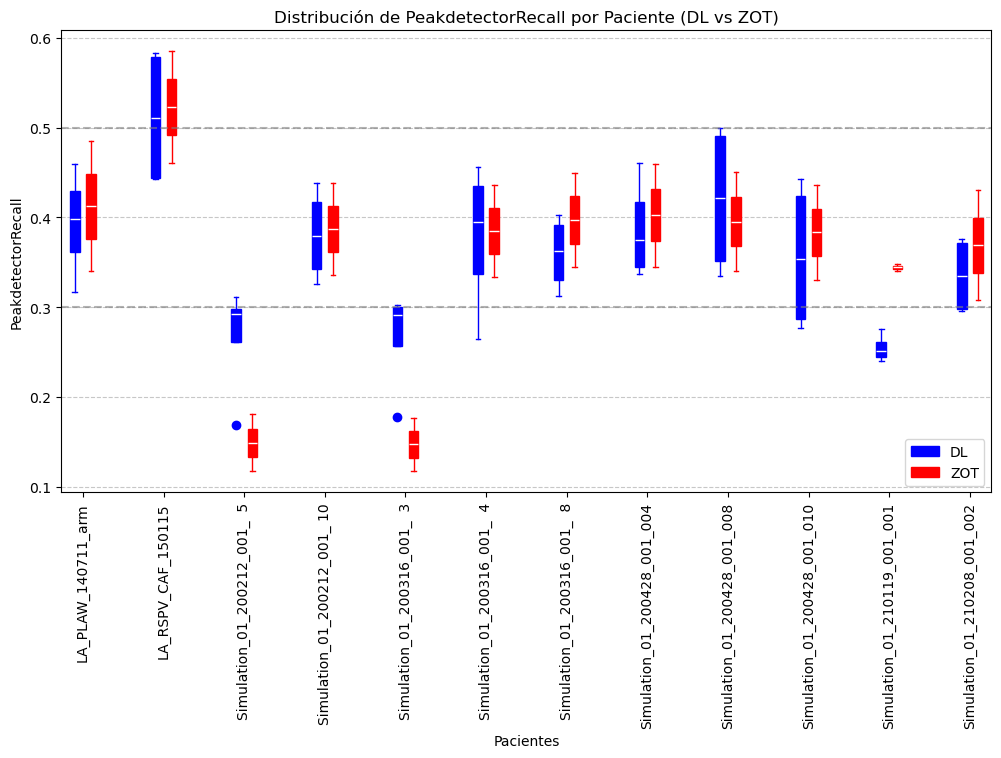

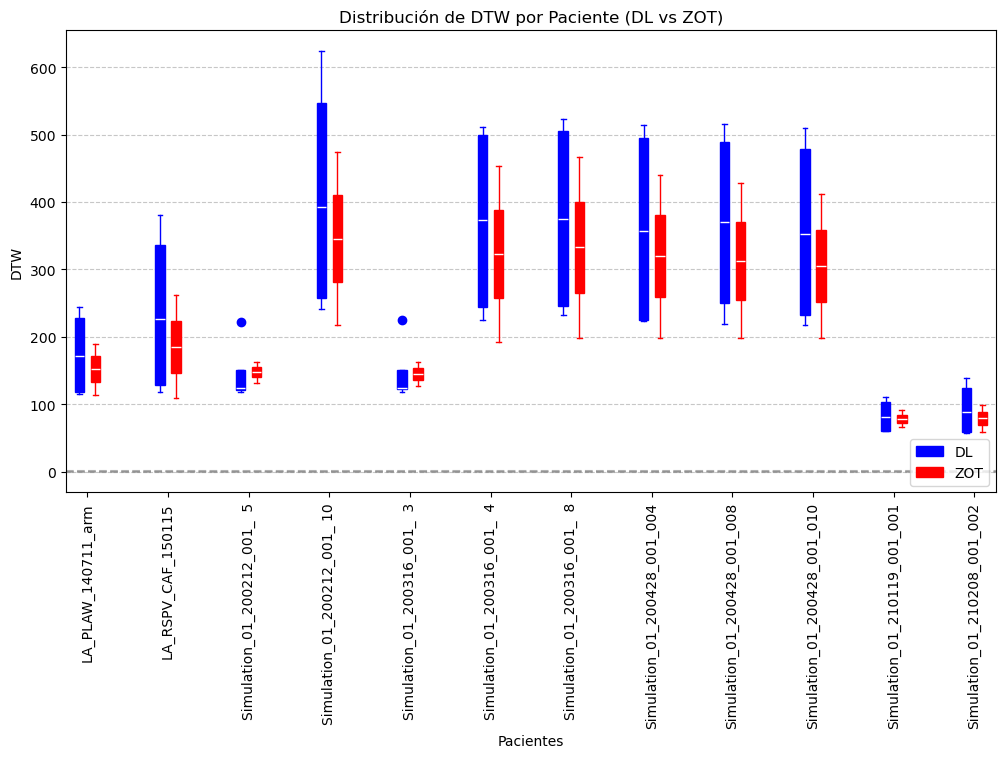

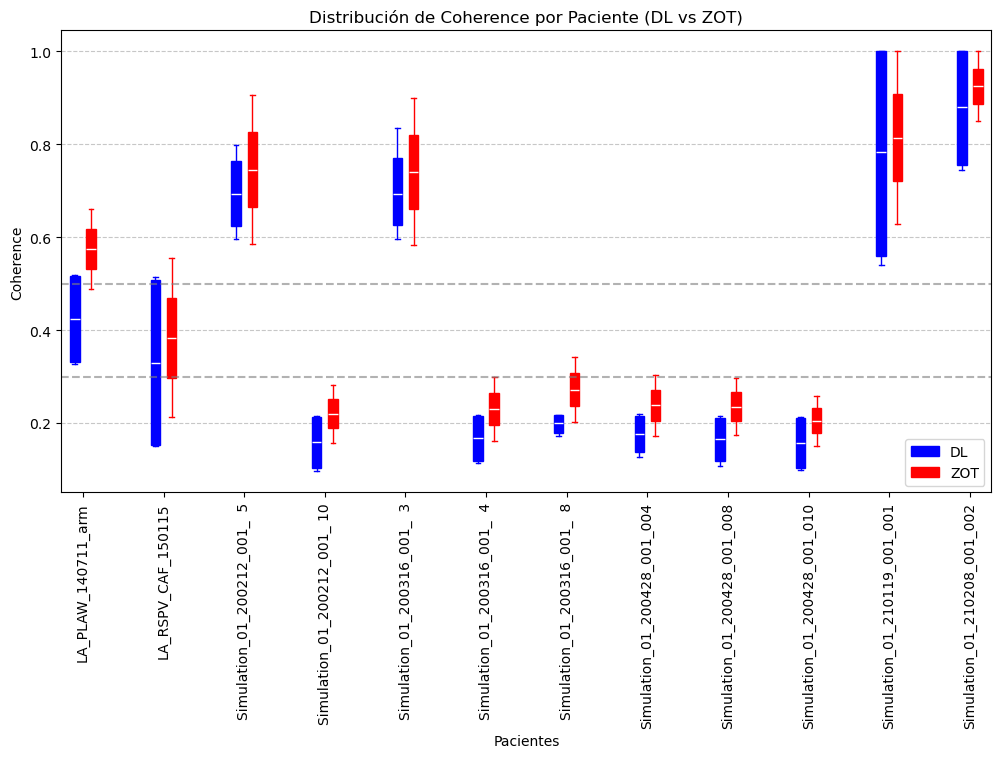

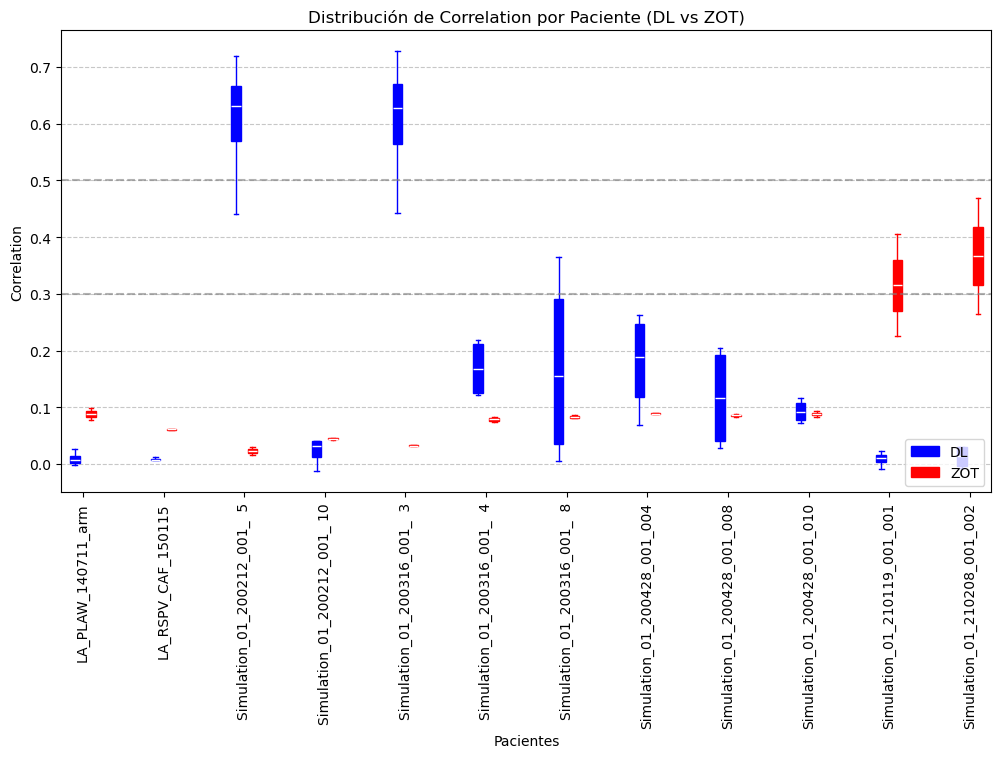

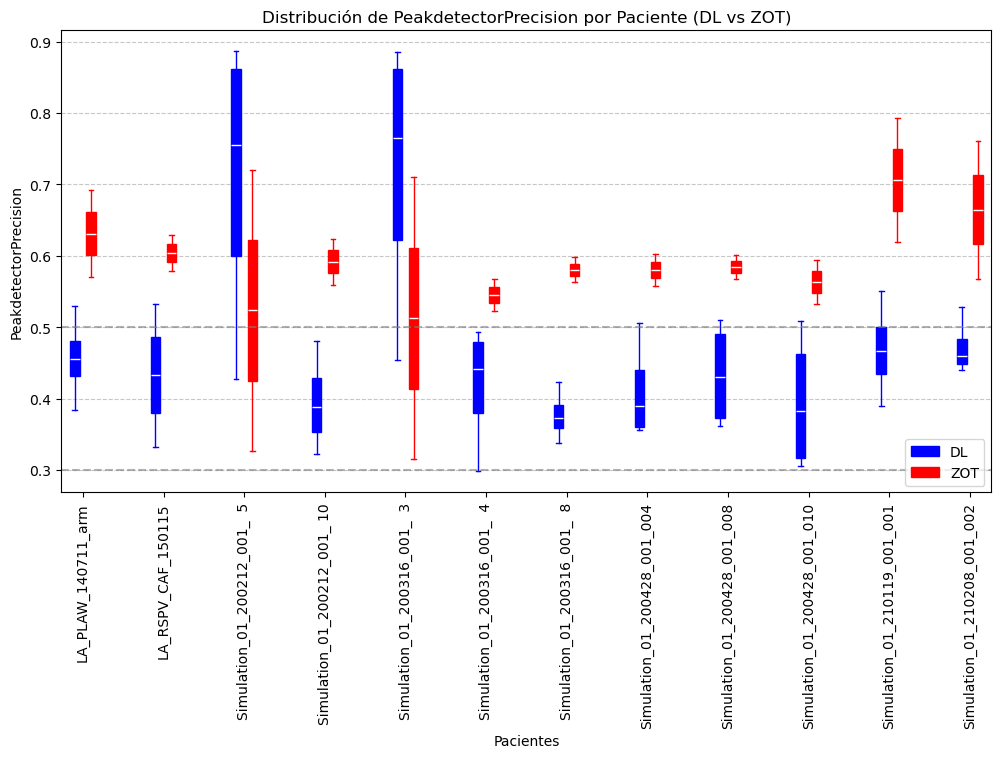

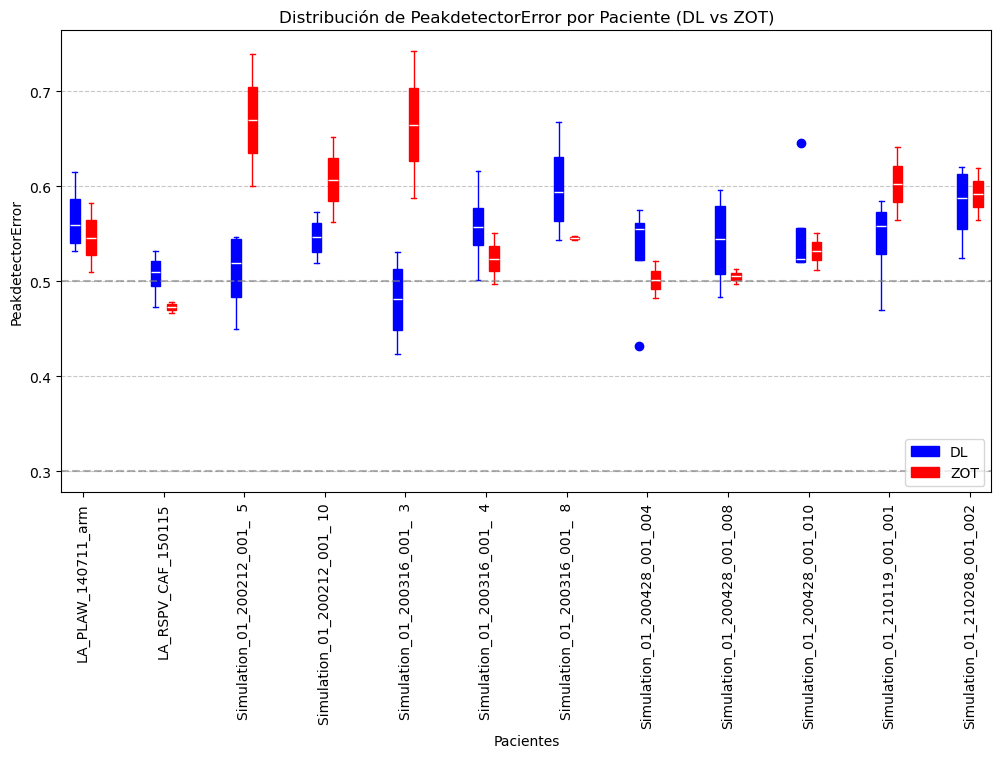

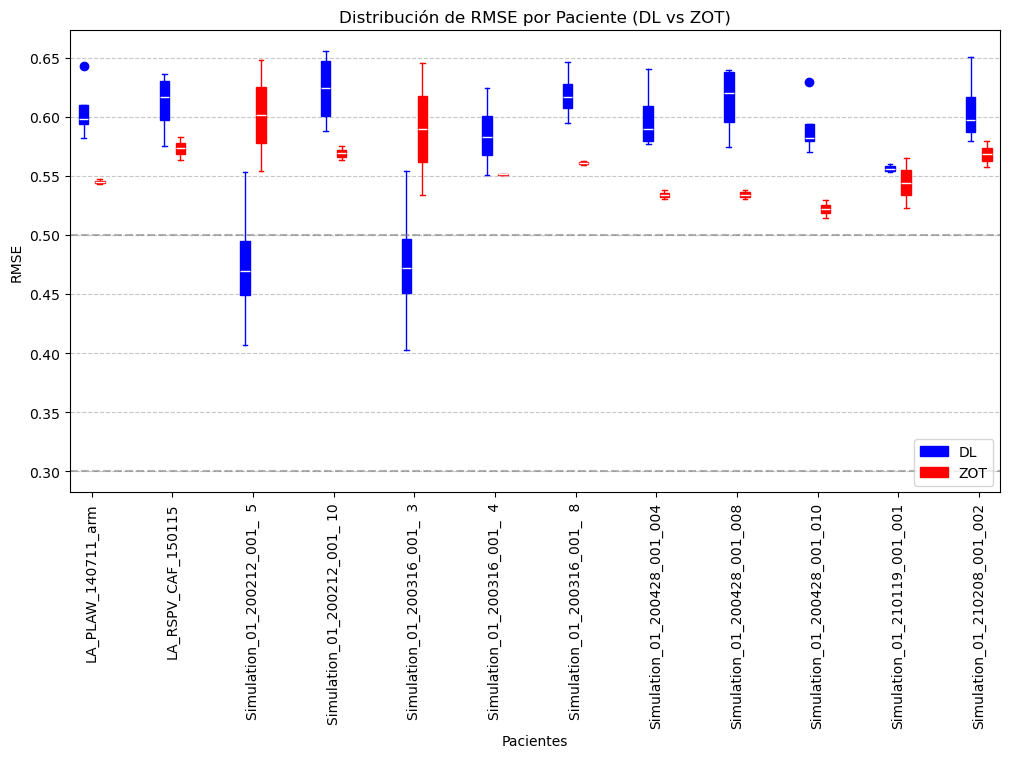

In [361]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches  # Para arreglar la leyenda

# 1️⃣ Iterar sobre cada métrica
for metric in common_metrics:
    if metric not in dl_grouped or metric not in tik_grouped:
        continue  # Ignorar métricas no comunes

    dl_columns = dl_grouped[metric]
    tik_columns = tik_grouped[metric]

    # 📌 Extraer datos por paciente
    dl_data = merged_df_dl[dl_columns]  # Todas las métricas DL para la métrica actual
    zot_data = df_tik_merged[tik_columns]  # Todas las métricas ZOT para la métrica actual

    # 📌 Crear figura
    plt.figure(figsize=(12, 6))

    # 📌 Posiciones de las cajas (DL y ZOT juntas, pero separadas de otros pacientes)
    num_pacientes = len(merged_df_dl)
    dl_positions = np.arange(num_pacientes) * 3  # Aumentamos la separación entre pacientes
    zot_positions = dl_positions + 0.6  # Acercamos DL y ZOT

    # 📊 Crear boxplots
    bp_dl = plt.boxplot(
        dl_data.values.T,  # Transponer para que cada paciente tenga su caja
        positions=dl_positions,
        widths=0.35,  # Reducimos el ancho para más separación
        patch_artist=True,
        boxprops=dict(facecolor="blue", color="blue"),
        medianprops=dict(color="white"),
        whiskerprops=dict(color="blue"),
        capprops=dict(color="blue"),
        flierprops=dict(markerfacecolor="blue", markeredgecolor="blue"),
    )

    bp_zot = plt.boxplot(
        zot_data.values.T,
        positions=zot_positions,
        widths=0.35,  # Reducimos el ancho
        patch_artist=True,
        boxprops=dict(facecolor="red", color="red"),
        medianprops=dict(color="white"),
        whiskerprops=dict(color="red"),
        capprops=dict(color="red"),
        flierprops=dict(markerfacecolor="red", markeredgecolor="red"),
    )

    # 📌 Etiquetas
    x_labels = merged_df_dl["name"]  # Nombre de los pacientes
    plt.xticks(dl_positions + 0.3, x_labels, rotation=90)  # Centrar entre DL y ZOT

    plt.title(f"Distribución de {metric} por Paciente (DL vs ZOT)")
    plt.xlabel("Pacientes")
    plt.ylabel(metric)
    
    # ✅ Corregir leyenda manualmente
    dl_patch = mpatches.Patch(color="blue", label="DL")
    zot_patch = mpatches.Patch(color="red", label="ZOT")
    plt.legend(handles=[dl_patch, zot_patch], loc="lower right")
    plt.axhline(y=0.5, color="gray", linestyle="--", alpha=0.6)
    plt.axhline(y=0.3, color="gray", linestyle="--", alpha=0.6)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # 📊 Mostrar gráfico
    plt.show()


ValueError: List of boxplot statistics and `positions` values must have same the length

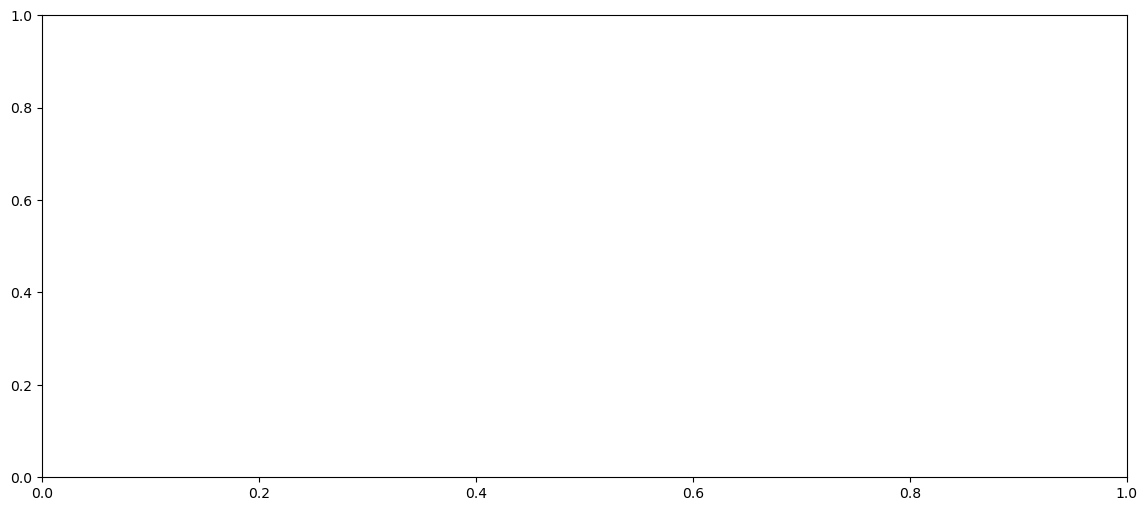

In [362]:
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Extraer las columnas de cada dataset
dl_columns = [col for col in merged_df_dl.columns if col != "name"]
tik_columns = [col for col in df_tik_merged.columns if col != "name"]

# Extraer las métricas comunes
dl_metrics = {col.split("_")[0] for col in dl_columns}
tik_metrics = {col.split("_")[0] for col in tik_columns}
common_metrics = dl_metrics.intersection(tik_metrics)

# 2️⃣ Agrupar columnas por métrica
dl_grouped = {metric: [col for col in dl_columns if col.startswith(metric)] for metric in common_metrics}
tik_grouped = {metric: [col for col in tik_columns if col.startswith(metric)] for metric in common_metrics}

# 3️⃣ Graficar DL y ZOT juntos para cada métrica
for metric in common_metrics:
    if metric not in dl_grouped or metric not in tik_grouped:
        continue  # Ignorar métricas que no están en ambos DataFrames

    dl_columns = dl_grouped[metric]
    tik_columns = tik_grouped[metric]

    # Unir los datos de DL y ZOT para las métricas comunes
    dl_data = merged_df_dl[dl_columns].mean(axis=1)  # Promedio de todos los algoritmos de DL
    zot_data = df_tik_merged[tik_columns].mean(axis=1)  # Promedio de `ZotFilt` y `ZotNoFilt`

    # Asegurar que el número de pacientes es el mismo
    common_patients = merged_df_dl["name"]

    # Verificar la longitud
    if len(dl_data) != len(zot_data):
        print(f"Error: Diferente número de datos en {metric}")
        continue

    plt.figure(figsize=(14, 6))

    # Crear posiciones para las cajas
    num_patients = len(common_patients)
    positions = np.arange(num_patients)  # Posiciones base
    dl_positions = positions * 2 - 0.2  # DL a la izquierda
    zot_positions = positions * 2 + 0.2  # ZOT a la derecha

    # Crear los boxplots para DL (Azul)
    bp_dl = plt.boxplot(
        [dl_data.values],  # Convertir en lista de listas
        positions=dl_positions,
        widths=0.3,
        patch_artist=True,
        boxprops=dict(facecolor="blue", color="blue"),
        medianprops=dict(color="white"),
        whiskerprops=dict(color="blue"),
        capprops=dict(color="blue"),
        flierprops=dict(markerfacecolor="blue", markeredgecolor="blue"),
    )

    # Crear los boxplots para ZOT (Rojo)
    bp_zot = plt.boxplot(
        [zot_data.values],  # Convertir en lista de listas
        positions=zot_positions,
        widths=0.3,
        patch_artist=True,
        boxprops=dict(facecolor="red", color="red"),
        medianprops=dict(color="white"),
        whiskerprops=dict(color="red"),
        capprops=dict(color="red"),
        flierprops=dict(markerfacecolor="red", markeredgecolor="red"),
    )

    # Añadir títulos y etiquetas
    plt.title(f"Distribución de {metric} por paciente (DL vs ZOT)")
    plt.xlabel("Pacientes")
    plt.ylabel(metric)
    plt.xticks(positions * 2, common_patients, rotation=90)  # Etiquetas centradas para los pacientes

    # Leyenda
    plt.legend([bp_dl["boxes"][0], bp_zot["boxes"][0]], ["DL", "ZOT"], loc="upper right")

    # Mostrar gráfico
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd

# Calcular la media y desviación estándar de todas las columnas numéricas
mean_row = merged_df.mean(numeric_only=True)
std_row = merged_df.std(numeric_only=True)

# Agregar un identificador a cada fila
mean_row["name"] = "Mean"
std_row["name"] = "Std"

# Convertir las filas en DataFrame y concatenarlas con el original
df = pd.concat([merged_df, pd.DataFrame([mean_row, std_row])], ignore_index=True)

# Mostrar las primeras 20 filas
df.head(20)




,name,Correlation_OMAMIrepeated,RMSE_OMAMIrepeated,PeakdetectorRecall_OMAMIrepeated,PeakdetectorPrecision_OMAMIrepeated,PeakdetectorError_OMAMIrepeated,DTW_OMAMIrepeated,Coherence_OMAMIrepeated,Correlation_OMAMIVAEOptuna1,RMSE_OMAMIVAEOptuna1,...,PeakdetectorError_ZotFilt,DTW_ZotFilt,Coherence_ZotFilt,Correlation_ZotNoFilt,RMSE_ZotNoFilt,PeakdetectorRecall_ZotNoFilt,PeakdetectorPrecision_ZotNoFilt,PeakdetectorError_ZotNoFilt,DTW_ZotNoFilt,Coherence_ZotNoFilt
0,LA_PLAW_140711_arm,0.026365,0.599248,0.377033,0.383743,0.542778,222.652928,0.327113,0.002061,0.582400,...,0.509337,113.629493,0.661241,0.099530,0.543128,0.340154,0.570221,0.582607,190.243763,0.489230
1,LA_RSPV_CAF_150115,0.006261,0.575233,0.442698,0.332110,0.517835,380.035551,0.150890,0.007589,0.635992,...,0.467173,108.966838,0.554812,0.061942,0.563192,0.461049,0.578393,0.478621,261.797972,0.212399
2,Simulation_01_200212_001_ 5,0.650290,0.475434,0.293163,0.853856,0.494584,222.404727,0.595684,0.613163,0.463047,...,0.600711,132.138408,0.905860,0.016105,0.648374,0.117389,0.326268,0.739036,163.512005,0.585867
3,Simulation_01_200212_001_ 10,0.040717,0.587912,0.347514,0.364322,0.519500,520.469808,0.106488,0.021692,0.604317,...,0.652061,216.958203,0.282199,0.046684,0.563038,0.335748,0.559721,0.562215,474.358111,0.158008
4,Simulation_01_200316_001_ 3,0.649851,0.477678,0.283443,0.852641,0.456898,225.096437,0.595278,0.605051,0.467132,...,0.587571,127.450310,0.898946,0.034181,0.645523,0.117177,0.315010,0.741841,163.088032,0.582723
5,Simulation_01_200316_001_ 4,0.218968,0.550739,0.360613,0.407846,0.564138,495.926404,0.114212,0.120840,0.572747,...,0.497196,193.188388,0.298627,0.083252,0.551032,0.333746,0.522077,0.550723,453.299620,0.161327
6,Simulation_01_200316_001_ 8,0.265425,0.621743,0.312336,0.338472,0.667957,499.332085,0.172630,0.005150,0.594923,...,0.548063,198.838845,0.342384,0.085865,0.558909,0.344610,0.563113,0.543215,466.789368,0.202172
7,Simulation_01_200428_001_004,0.240863,0.599347,0.346866,0.355691,0.557125,514.723405,0.126478,0.068573,0.580690,...,0.482553,198.448331,0.302987,0.090211,0.530151,0.345263,0.557552,0.520998,440.609652,0.172931
8,Simulation_01_200428_001_008,0.205031,0.574364,0.334343,0.361496,0.573320,480.817674,0.122760,0.044184,0.603139,...,0.497598,197.833254,0.296542,0.088632,0.530313,0.340042,0.567332,0.513133,428.137785,0.174387
9,Simulation_01_200428_001_010,0.079154,0.582373,0.289576,0.320659,0.520368,467.422401,0.103635,0.116488,0.570314,...,0.551255,198.968192,0.258883,0.093116,0.514760,0.330864,0.532333,0.512293,412.495147,0.150470


In [ ]:
import pandas as pd

# Extraer nombres únicos de métricas eliminando los nombres de algoritmos
metric_names = list(set(col.split("_OMAMI")[0] for col in merged_df.columns if "_OMAMI" in col))

# Crear un diccionario vacío para almacenar los resultados
metrics_summary = {}

# Iterar sobre cada algoritmo y calcular la media y std para cada métrica
for algorithm in algorithm_mod_name:
    metric_values = {}
    for metric in metric_names:
        # Filtrar columnas que contienen la métrica y el algoritmo
        algorithm_cols = [col for col in merged_df.columns if metric in col and algorithm in col]
        
        # Calcular la media y std solo para estas columnas
        if algorithm_cols:
            metric_values[metric] = {
                "Mean": merged_df[algorithm_cols].mean(numeric_only=True).mean(),
                "Std": merged_df[algorithm_cols].std(numeric_only=True).mean()
            }

    # Guardar en el diccionario con el nombre del algoritmo
    metrics_summary[algorithm] = pd.DataFrame(metric_values).T

# Concatenar los DataFrames de cada algoritmo con MultiIndex
summary_df = pd.concat(metrics_summary, axis=1)
summary_df=summary_df.T
# Mostrar el nuevo DataFrame estructurado
summary_df.head(20)


PeakdetectorRecall         DTW  Coherence  Correlation  \
OMAMIrepeated   Mean            0.327706  355.844004   0.309707     0.200375   
                Std             0.052065  161.015182   0.243962     0.231886   
OMAMIVAEOptuna1 Mean            0.414198  163.194050   0.496429     0.135128   
                Std             0.087265   69.551751   0.328029     0.225416   
OMAMInofilt     Mean            0.315538  351.499220   0.317689     0.219055   
                Std             0.052642  196.976333   0.252681     0.263441   
OMAMIVAEnofilt  Mean            0.378593  174.674339   0.484097     0.111401   
                Std             0.121965   80.271563   0.318873     0.160820   
ZotFilt         Mean            0.406390  150.991126   0.566873     0.094836   
                Std             0.118635   56.279223   0.309016     0.073213   
ZotNoFilt       Mean            0.309546  303.743069   0.364103     0.131130   
                Std             0.097212  155.247699   0.246862     0.145851   

                      PeakdetectorPrecision  PeakdetectorError      RMSE  
OMAMIrepeated   Mean               0.457887           0.550362  0.571223  
                Std                0.190467           0.056176  0.051619  
OMAMIVAEOptuna1 Mean               0.569503           0.518653  0.569798  
                Std                0.151211           0.054990  0.053067  
OMAMInofilt     Mean               0.427095           0.580394  0.585310  
                Std                0.125070           0.040275  0.088799  
OMAMIVAEnofilt  Mean               0.439311           0.521502  0.593561  
                Std                0.033969           0.038434  0.033808  
ZotFilt         Mean               0.657736           0.543602  0.554710  
                Std                0.074344           0.054732  0.018378  
ZotNoFilt       Mean               0.523286           0.583732  0.560733  
                Std                0.097596           0.086291  0.043373

In [265]:
import pandas as pd

# Copiar el DataFrame original para no modificarlo
df_formatted = summary_df.copy()

# Asegurar que el índice sea un MultiIndex con [algoritmo, estadística (Mean/Std)]
if isinstance(df_formatted.index, pd.MultiIndex):
    # Aplicar la transformación Mean ± Std por cada métrica
    df_mean = np.round(df_formatted.xs('Mean', level=1),4)  # Extraer solo la fila de "Mean"
    df_std = np.round(df_formatted.xs('Std', level=1),2)  # Extraer solo la fila de "Std"

    # Combinar los valores en el formato "mean ± std"
    df_result = df_mean.astype(str) + " ± " + df_std.astype(str)

    # Mostrar el nuevo DataFrame
    

else:
    print("Error: El DataFrame no tiene un MultiIndex con niveles (algoritmo, estadística).")

#reorder columns
common_columns = [col for col in df_dl.columns if col in df_result.columns]
df_result = df_result[common_columns]

path_to_save="/home/pdi/miriamgf/tesis/Autoencoders/code/egm_reconstruction/Code/output/evaluation/Global_results/global_results.csv"
df_result.to_csv(path_to_save, index=True)

df_result.head(20)


,Correlation,RMSE,PeakdetectorRecall,PeakdetectorPrecision,PeakdetectorError,DTW,Coherence
OMAMIrepeated,0.2004 ± 0.23,0.5712 ± 0.05,0.3277 ± 0.05,0.4579 ± 0.19,0.5504 ± 0.06,355.844 ± 161.02,0.3097 ± 0.24
OMAMIVAEOptuna1,0.1351 ± 0.23,0.5698 ± 0.05,0.4142 ± 0.09,0.5695 ± 0.15,0.5187 ± 0.05,163.1941 ± 69.55,0.4964 ± 0.33
OMAMInofilt,0.2191 ± 0.26,0.5853 ± 0.09,0.3155 ± 0.05,0.4271 ± 0.13,0.5804 ± 0.04,351.4992 ± 196.98,0.3177 ± 0.25
OMAMIVAEnofilt,0.1114 ± 0.16,0.5936 ± 0.03,0.3786 ± 0.12,0.4393 ± 0.03,0.5215 ± 0.04,174.6743 ± 80.27,0.4841 ± 0.32
ZotFilt,0.0948 ± 0.07,0.5547 ± 0.02,0.4064 ± 0.12,0.6577 ± 0.07,0.5436 ± 0.05,150.9911 ± 56.28,0.5669 ± 0.31
ZotNoFilt,0.1311 ± 0.15,0.5607 ± 0.04,0.3095 ± 0.1,0.5233 ± 0.1,0.5837 ± 0.09,303.7431 ± 155.25,0.3641 ± 0.25


In [284]:
import pandas as pd

# Paso 1: Extraer los nombres de las métricas sin el sufijo del algoritmo
metric_columns = [col for col in merged_df.columns if col != "name"]
metric_dict = {col: col.split("_")[0] for col in metric_columns}  # Extraer solo la métrica

# Paso 2: Renombrar las columnas para agrupar métricas con el mismo nombre
df_metrics = merged_df.rename(columns=metric_dict)

# ⚠️ EXCLUIR la columna "name" antes de calcular la media
df_numeric = df_metrics.drop(columns=["name"])

# Paso 3: Agrupar columnas con el mismo nombre y calcular la media en cada fila
df_mean_metrics = df_numeric.groupby(axis=1, level=0).mean()

# Paso 4: Reinsertar la columna "name" para identificar a cada paciente
df_mean_metrics.insert(0, "name", merged_df["name"])

df_mean_metrics.head()



/tmp/ipykernel_563511/2290724369.py:14: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_mean_metrics = df_numeric.groupby(axis=1, level=0).mean()


,name,Coherence,Correlation,DTW,PeakdetectorError,PeakdetectorPrecision,PeakdetectorRecall,RMSE
0,LA_PLAW_140711_arm,0.474005,0.035496,167.630420,0.559711,0.514560,0.399741,0.585254
1,LA_RSPV_CAF_150115,0.348375,0.025702,220.545697,0.495138,0.489675,0.515479,0.598374
2,Simulation_01_200212_001_ 5,0.712108,0.411612,147.640051,0.562387,0.645313,0.227185,0.516904
3,Simulation_01_200212_001_ 10,0.178198,0.029861,389.984413,0.566579,0.460235,0.382603,0.605077
4,Simulation_01_200316_001_ 3,0.716265,0.414871,147.254070,0.541222,0.649191,0.226203,0.513471


In [269]:
merged_df

,name,Correlation_OMAMIrepeated,RMSE_OMAMIrepeated,PeakdetectorRecall_OMAMIrepeated,PeakdetectorPrecision_OMAMIrepeated,PeakdetectorError_OMAMIrepeated,DTW_OMAMIrepeated,Coherence_OMAMIrepeated,Correlation_OMAMIVAEOptuna1,RMSE_OMAMIVAEOptuna1,...,PeakdetectorError_ZotFilt,DTW_ZotFilt,Coherence_ZotFilt,Correlation_ZotNoFilt,RMSE_ZotNoFilt,PeakdetectorRecall_ZotNoFilt,PeakdetectorPrecision_ZotNoFilt,PeakdetectorError_ZotNoFilt,DTW_ZotNoFilt,Coherence_ZotNoFilt
0,LA_PLAW_140711_arm,0.026365,0.599248,0.377033,0.383743,0.542778,222.652928,0.327113,0.002061,0.582400,...,0.509337,113.629493,0.661241,0.099530,0.543128,0.340154,0.570221,0.582607,190.243763,0.489230
1,LA_RSPV_CAF_150115,0.006261,0.575233,0.442698,0.332110,0.517835,380.035551,0.150890,0.007589,0.635992,...,0.467173,108.966838,0.554812,0.061942,0.563192,0.461049,0.578393,0.478621,261.797972,0.212399
2,Simulation_01_200212_001_ 5,0.650290,0.475434,0.293163,0.853856,0.494584,222.404727,0.595684,0.613163,0.463047,...,0.600711,132.138408,0.905860,0.016105,0.648374,0.117389,0.326268,0.739036,163.512005,0.585867
3,Simulation_01_200212_001_ 10,0.040717,0.587912,0.347514,0.364322,0.519500,520.469808,0.106488,0.021692,0.604317,...,0.652061,216.958203,0.282199,0.046684,0.563038,0.335748,0.559721,0.562215,474.358111,0.158008
4,Simulation_01_200316_001_ 3,0.649851,0.477678,0.283443,0.852641,0.456898,225.096437,0.595278,0.605051,0.467132,...,0.587571,127.450310,0.898946,0.034181,0.645523,0.117177,0.315010,0.741841,163.088032,0.582723
5,Simulation_01_200316_001_ 4,0.218968,0.550739,0.360613,0.407846,0.564138,495.926404,0.114212,0.120840,0.572747,...,0.497196,193.188388,0.298627,0.083252,0.551032,0.333746,0.522077,0.550723,453.299620,0.161327
6,Simulation_01_200316_001_ 8,0.265425,0.621743,0.312336,0.338472,0.667957,499.332085,0.172630,0.005150,0.594923,...,0.548063,198.838845,0.342384,0.085865,0.558909,0.344610,0.563113,0.543215,466.789368,0.202172
7,Simulation_01_200428_001_004,0.240863,0.599347,0.346866,0.355691,0.557125,514.723405,0.126478,0.068573,0.580690,...,0.482553,198.448331,0.302987,0.090211,0.530151,0.345263,0.557552,0.520998,440.609652,0.172931
8,Simulation_01_200428_001_008,0.205031,0.574364,0.334343,0.361496,0.573320,480.817674,0.122760,0.044184,0.603139,...,0.497598,197.833254,0.296542,0.088632,0.530313,0.340042,0.567332,0.513133,428.137785,0.174387
9,Simulation_01_200428_001_010,0.079154,0.582373,0.289576,0.320659,0.520368,467.422401,0.103635,0.116488,0.570314,...,0.551255,198.968192,0.258883,0.093116,0.514760,0.330864,0.532333,0.512293,412.495147,0.150470


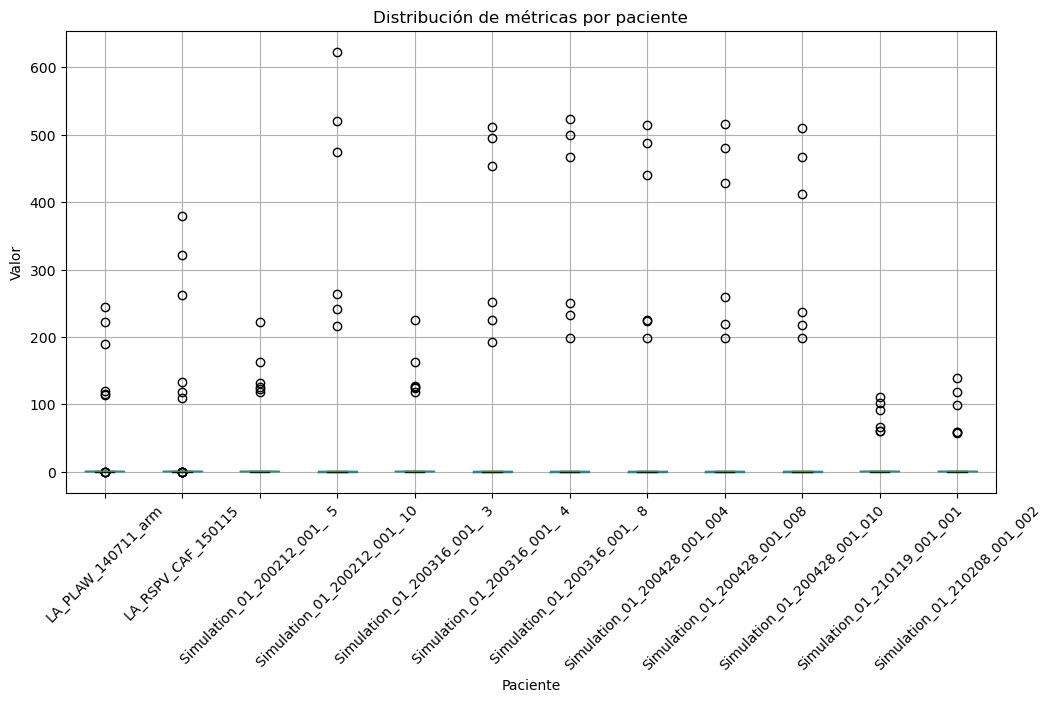

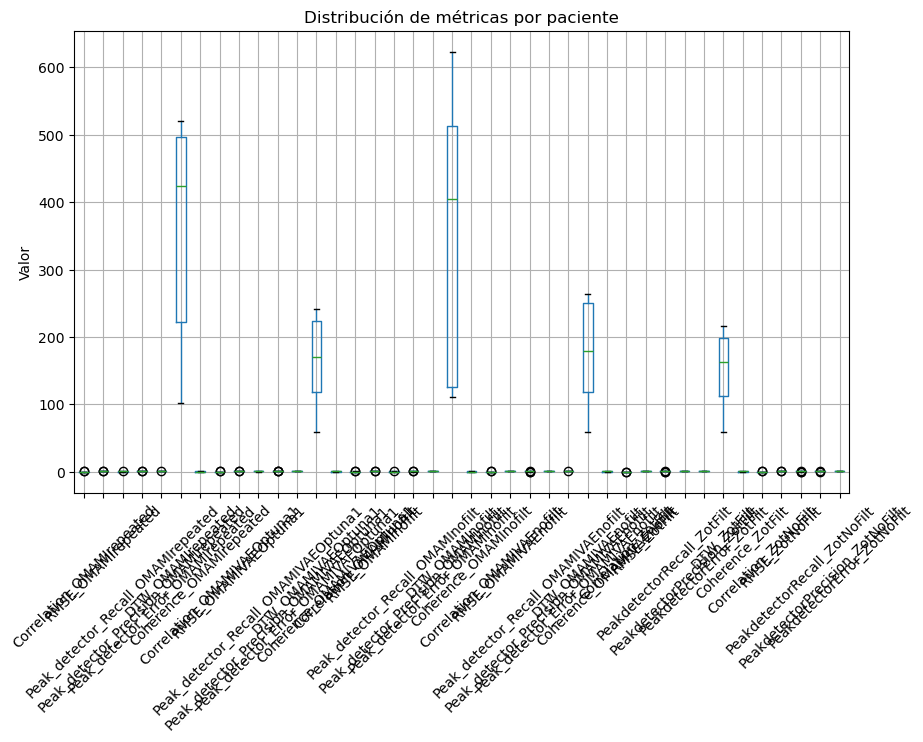

In [259]:
# Transponer el DataFrame para que cada fila (paciente) tenga su propio boxplot
df_boxplot = merged_df.set_index("name").T  # Poner "name" como índice y transponer

# Crear el boxplot
plt.figure(figsize=(12, 6))
df_boxplot.boxplot()

# Personalizar la visualización
plt.title("Distribución de métricas por paciente")
plt.xticks(rotation=45)  # Rotar etiquetas para mejor visualización
plt.ylabel("Valor")
plt.xlabel("Paciente")
plt.show()

plt.figure(figsize=(10, 6))
merged_df.iloc[:, 1:-2].boxplot()  # Excluye la columna 'name' y las nuevas columnas 'Mean' y 'Std'
plt.title("Distribución de métricas por paciente")
plt.xticks(rotation=45)
plt.ylabel("Valor")
plt.show()


In [260]:
merged_df["Mean"] = df.iloc[:, 1:].mean(axis=1)
merged_df["Std"] = df.iloc[:, 1:].std(axis=1)

In [261]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

patient_name = 'LA_RSPV_CAF_150115'  # Cambia esto por el paciente que deseas analizar


# Suponiendo que `merged_df` ya está creado
# Seleccionar las métricas y los algoritmos
metrics = ['Correlation', 'RMSE', 'Peak_detector_Recall', 'Peak_detector_Precision', 'DTW', 'Coherence']
algorithms = algorithm_mod_name

# Reorganizar el DataFrame al formato largo
long_df = merged_df.melt(
    id_vars=['name'],  # Mantener la columna 'name'
    value_vars=[f"{metric}_{algo}" for algo in algorithms for metric in metrics],
    var_name='metric_algorithm',  # Nueva columna que combina métricas y algoritmos
    value_name='value'  # Columna para los valores de las métricas
)

# Dividir 'metric_algorithm' en 'metric' y 'algorithm'
long_df[['metric', 'algorithm']] = long_df['metric_algorithm'].str.rsplit('_', n=1, expand=True)

# Seleccionar un paciente específico
patient_data = long_df[long_df['name'] == patient_name]

# Crear un gráfico de barras separado para cada métrica
plt.figure(figsize=(8, 5))
for metric in metrics:
    
    sns.barplot(
        data=patient_data[patient_data['metric'] == metric],
        x='algorithm',  # Algoritmo en el eje X
        y='value',  # Valor en el eje Y
    )
    plt.title(f'{metric} Comparison for Patient: {patient_name}')
    plt.ylabel('Metric Value')
    plt.xlabel('Algorithm')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()


KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['Peak_detector_Recall_ZotFilt', 'Peak_detector_Precision_ZotFilt', 'Peak_detector_Recall_ZotNoFilt', 'Peak_detector_Precision_ZotNoFilt']"

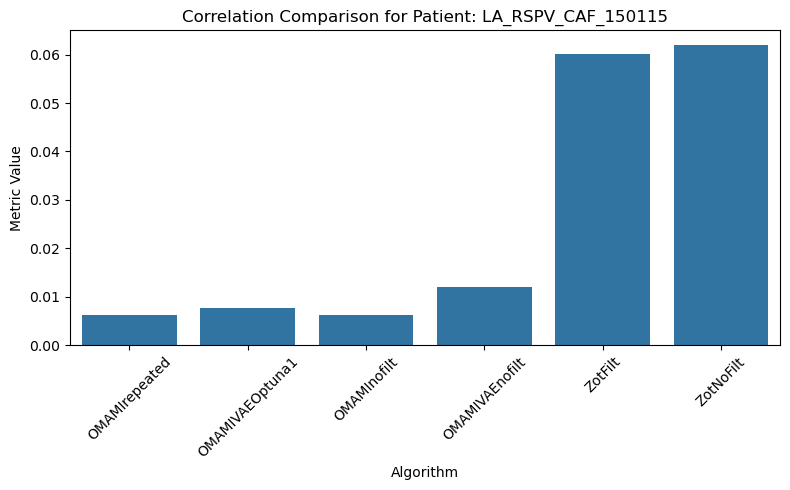

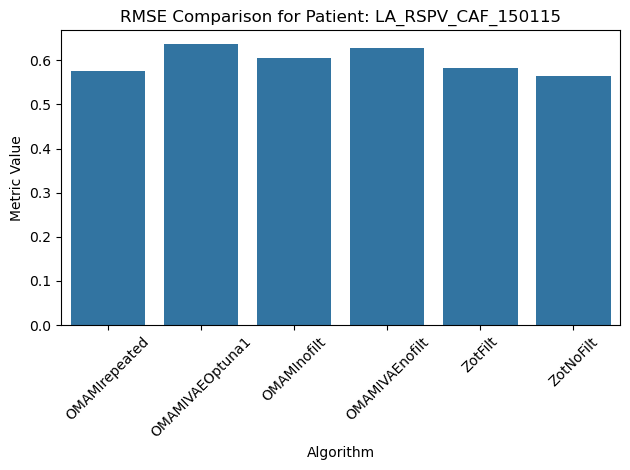

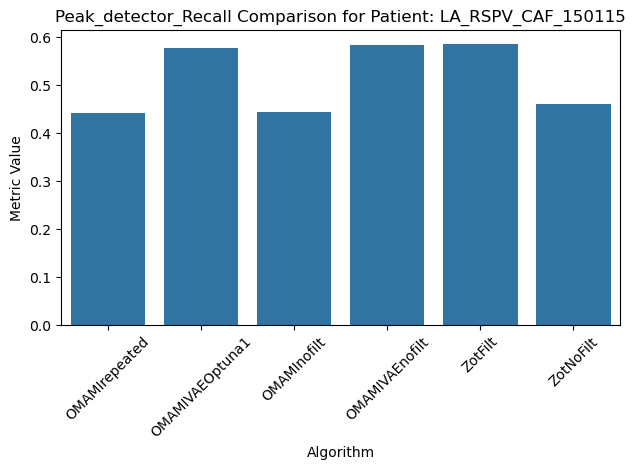

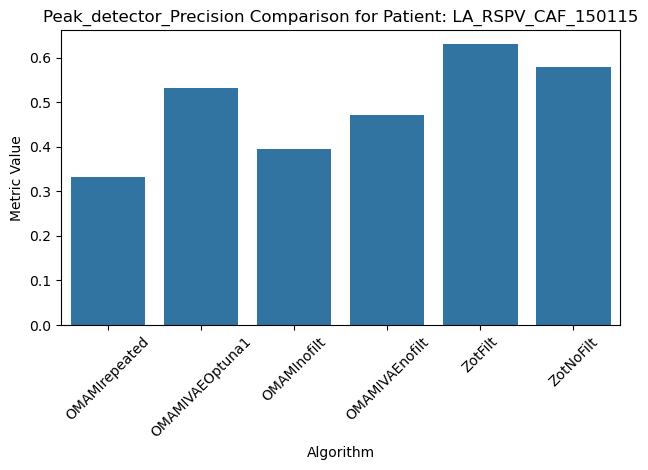

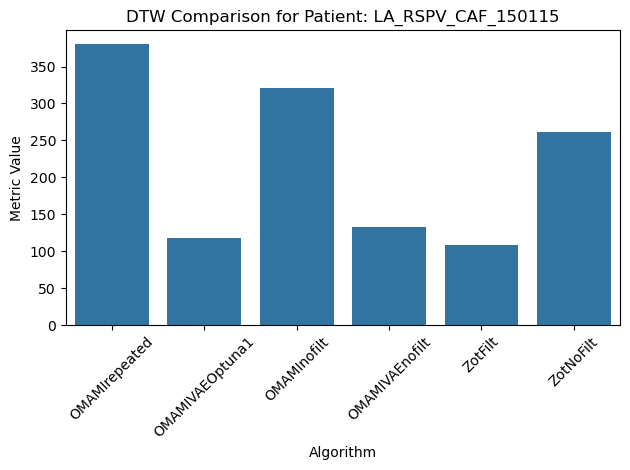

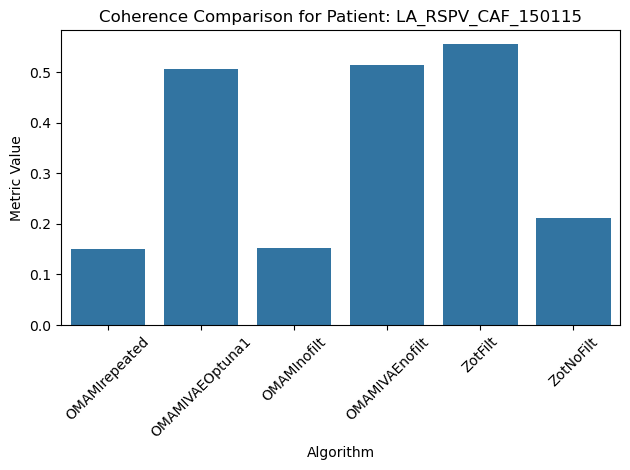

In [ ]:
patient_name = 'LA_RSPV_CAF_150115'  # Cambia esto por el paciente que deseas analizar


# Suponiendo que `merged_df` ya está creado
# Seleccionar las métricas y los algoritmos
metrics = ['Correlation', 'RMSE', 'Peak_detector_Recall', 'Peak_detector_Precision', 'DTW', 'Coherence']
algorithms = algorithm_mod_name

# Reorganizar el DataFrame al formato largo
long_df = merged_df.melt(
    id_vars=['name'],  # Mantener la columna 'name'
    value_vars=[f"{metric}_{algo}" for algo in algorithms for metric in metrics],
    var_name='metric_algorithm',  # Nueva columna que combina métricas y algoritmos
    value_name='value'  # Columna para los valores de las métricas
)

# Dividir 'metric_algorithm' en 'metric' y 'algorithm'
long_df[['metric', 'algorithm']] = long_df['metric_algorithm'].str.rsplit('_', n=1, expand=True)

# Seleccionar un paciente específico
patient_data = long_df[long_df['name'] == patient_name]

# Ajustar el tamaño de la figura para cada métrica
plt.figure(figsize=(8, 5))

# Iterar por cada métrica en el conjunto de métricas
for metric in metrics:
    # Filtrar los datos para la métrica actual
    data_for_metric = patient_data[patient_data['metric'] == metric]
    
    # Crear un gráfico de barras para la métrica actual
    sns.barplot(
        data=data_for_metric,
        x='algorithm',  # Algoritmo en el eje X
        y='value'       # Valor en el eje Y
    )
    
    # Configurar el título y las etiquetas
    plt.title(f'{metric} Comparison for Patient: {patient_name}')
    plt.ylabel('Metric Value')
    plt.xlabel('Algorithm')
    plt.xticks(rotation=45)  # Rotar las etiquetas en el eje X
    plt.tight_layout()       # Ajustar el diseño para evitar solapamientos
    
    # Guardar el gráfico como imagen
    plt.savefig(f'{output_path}/{metric}_comparison_{patient_name}.png')
    
    # Mostrar el gráfico
    plt.show()

/tmp/ipykernel_563511/1910103773.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


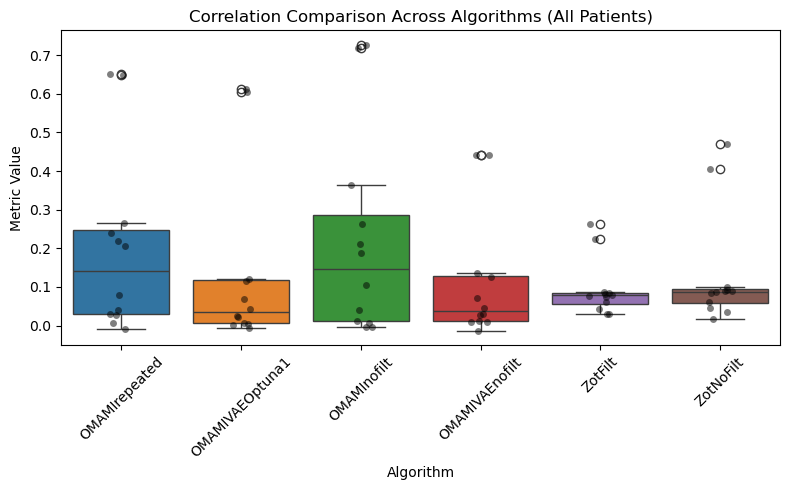

/tmp/ipykernel_563511/1910103773.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


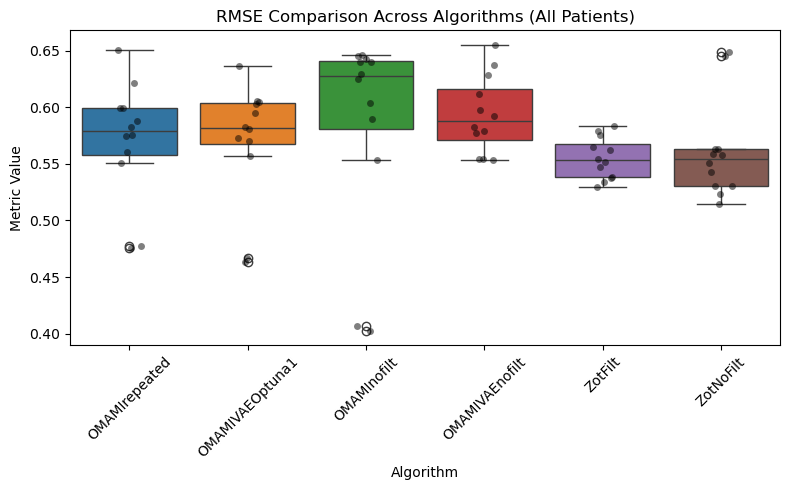

/tmp/ipykernel_563511/1910103773.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


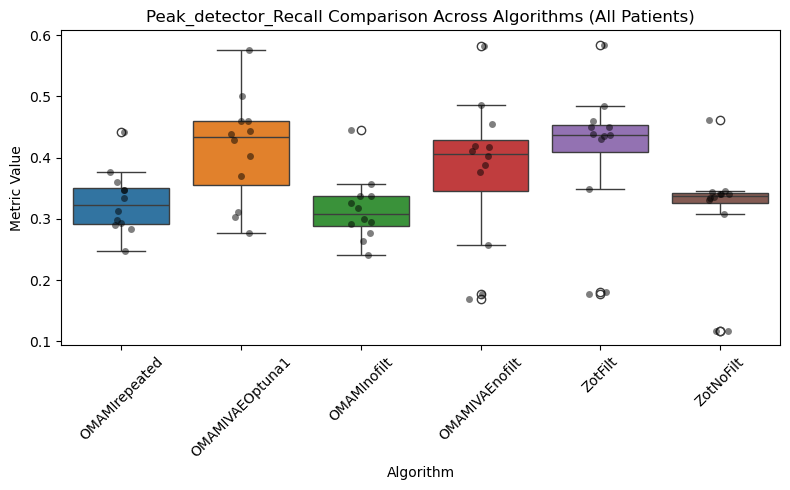

/tmp/ipykernel_563511/1910103773.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


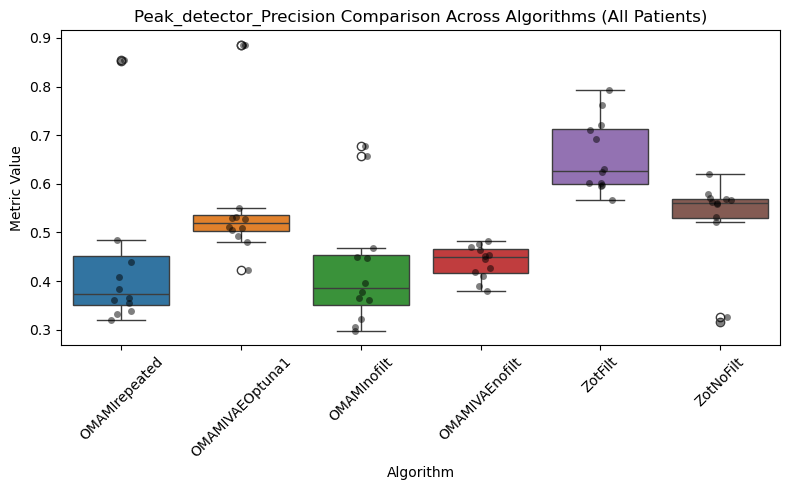

/tmp/ipykernel_563511/1910103773.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


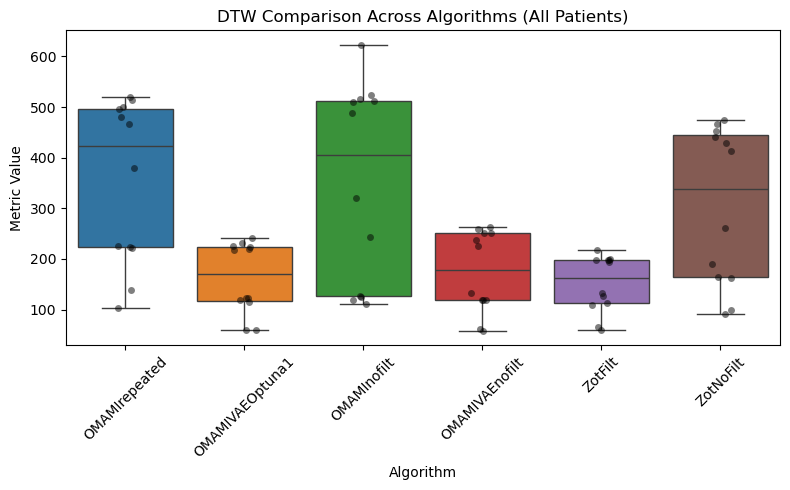

/tmp/ipykernel_563511/1910103773.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


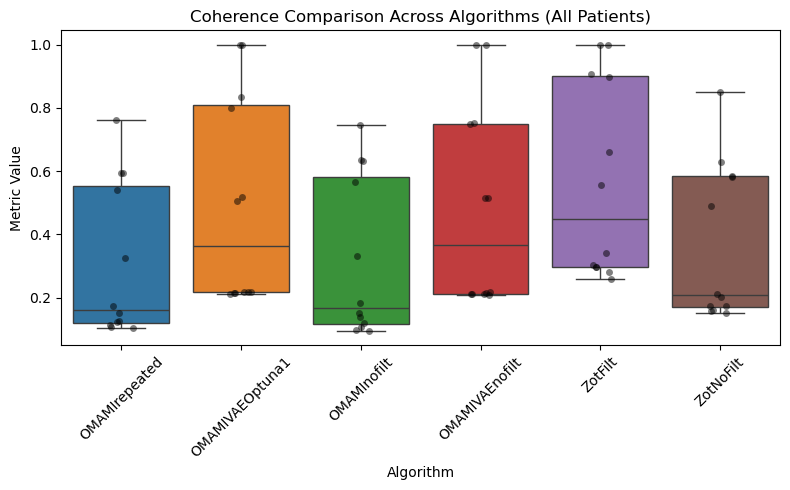

In [235]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Obtener todas las métricas únicas
metrics = long_df['metric'].unique()

# Generar un gráfico por cada métrica usando todos los valores de los pacientes
for metric in metrics:
    plt.figure(figsize=(8, 5))  # Crear una nueva figura para cada métrica
    
    # Filtrar datos para la métrica actual (TODOS los valores de los pacientes)
    metric_data = long_df[long_df['metric'] == metric]

    
    # Crear el boxplot con la distribución real de los valores
    sns.boxplot(
        data=metric_data,
        x='algorithm',
        y='value',
        palette="tab10"  # Diferenciar algoritmos con colores
    )
    
    # Agregar puntos individuales (jitter) para ver la dispersión de los pacientes
    sns.stripplot(
        data=metric_data,
        x='algorithm',
        y='value',
        color="black",
        alpha=0.5,  # Transparencia para mejor visualización
        jitter=True  # Separar puntos para que no se sobrepongan
    )
    
    # Configurar el título y etiquetas
    plt.title(f'{metric} Comparison Across Algorithms (All Patients)')
    plt.ylabel('Metric Value')
    plt.xlabel('Algorithm')
    plt.xticks(rotation=45)  # Rotar etiquetas del eje X para mejor lectura

    # Ajustar el diseño
    plt.tight_layout()
    
    # Guardar el gráfico como imagen
    plt.savefig(f'{output_path}/boxplot_{metric}.png')

    # Mostrar el gráfico
    plt.show()





['LA_PLAW_140711_arm' 'LA_RSPV_CAF_150115' 'Simulation_01_200212_001_  5'
 'Simulation_01_200212_001_ 10' 'Simulation_01_200316_001_  3'
 'Simulation_01_200316_001_  4' 'Simulation_01_200316_001_  8'
 'Simulation_01_200428_001_004' 'Simulation_01_200428_001_008'
 'Simulation_01_200428_001_010' 'Simulation_01_210119_001_001'
 'Simulation_01_210208_001_002']
                   name                         metric_algorithm       value  \
0    LA_PLAW_140711_arm                Correlation_OMAMIrepeated    0.026365   
12   LA_PLAW_140711_arm                       RMSE_OMAMIrepeated    0.599248   
24   LA_PLAW_140711_arm       Peak_detector_Recall_OMAMIrepeated    0.377033   
36   LA_PLAW_140711_arm    Peak_detector_Precision_OMAMIrepeated    0.383743   
48   LA_PLAW_140711_arm                        DTW_OMAMIrepeated  222.652928   
60   LA_PLAW_140711_arm                  Coherence_OMAMIrepeated    0.327113   
72   LA_PLAW_140711_arm              Correlation_OMAMIVAEOptuna1    0.002061   
8

/tmp/ipykernel_563511/4116899852.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


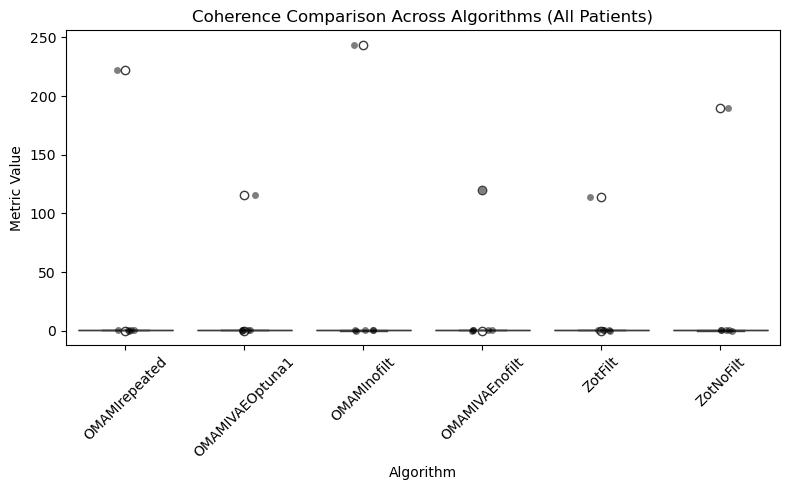

                   name                         metric_algorithm       value  \
1    LA_RSPV_CAF_150115                Correlation_OMAMIrepeated    0.006261   
13   LA_RSPV_CAF_150115                       RMSE_OMAMIrepeated    0.575233   
25   LA_RSPV_CAF_150115       Peak_detector_Recall_OMAMIrepeated    0.442698   
37   LA_RSPV_CAF_150115    Peak_detector_Precision_OMAMIrepeated    0.332110   
49   LA_RSPV_CAF_150115                        DTW_OMAMIrepeated  380.035551   
61   LA_RSPV_CAF_150115                  Coherence_OMAMIrepeated    0.150890   
73   LA_RSPV_CAF_150115              Correlation_OMAMIVAEOptuna1    0.007589   
85   LA_RSPV_CAF_150115                     RMSE_OMAMIVAEOptuna1    0.635992   
97   LA_RSPV_CAF_150115     Peak_detector_Recall_OMAMIVAEOptuna1    0.576390   
109  LA_RSPV_CAF_150115  Peak_detector_Precision_OMAMIVAEOptuna1    0.531855   
121  LA_RSPV_CAF_150115                      DTW_OMAMIVAEOptuna1  118.366450   
133  LA_RSPV_CAF_150115                C

/tmp/ipykernel_563511/4116899852.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


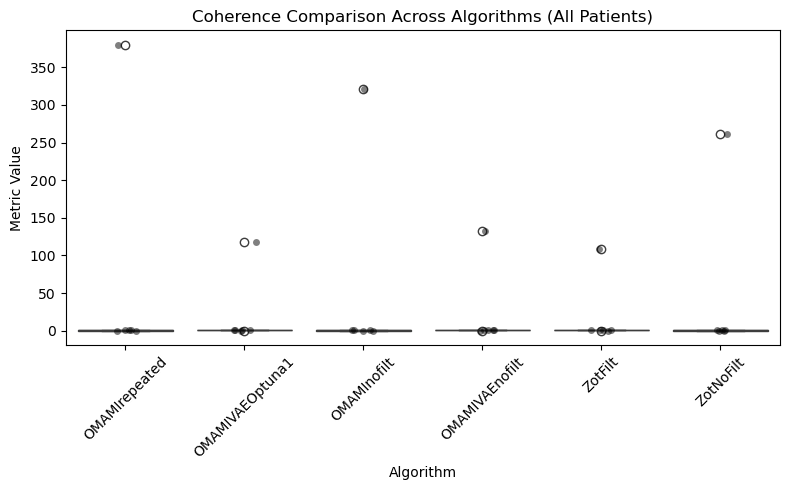

                             name                         metric_algorithm  \
2    Simulation_01_200212_001_  5                Correlation_OMAMIrepeated   
14   Simulation_01_200212_001_  5                       RMSE_OMAMIrepeated   
26   Simulation_01_200212_001_  5       Peak_detector_Recall_OMAMIrepeated   
38   Simulation_01_200212_001_  5    Peak_detector_Precision_OMAMIrepeated   
50   Simulation_01_200212_001_  5                        DTW_OMAMIrepeated   
62   Simulation_01_200212_001_  5                  Coherence_OMAMIrepeated   
74   Simulation_01_200212_001_  5              Correlation_OMAMIVAEOptuna1   
86   Simulation_01_200212_001_  5                     RMSE_OMAMIVAEOptuna1   
98   Simulation_01_200212_001_  5     Peak_detector_Recall_OMAMIVAEOptuna1   
110  Simulation_01_200212_001_  5  Peak_detector_Precision_OMAMIVAEOptuna1   
122  Simulation_01_200212_001_  5                      DTW_OMAMIVAEOptuna1   
134  Simulation_01_200212_001_  5                Coherence_OMAMI

/tmp/ipykernel_563511/4116899852.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


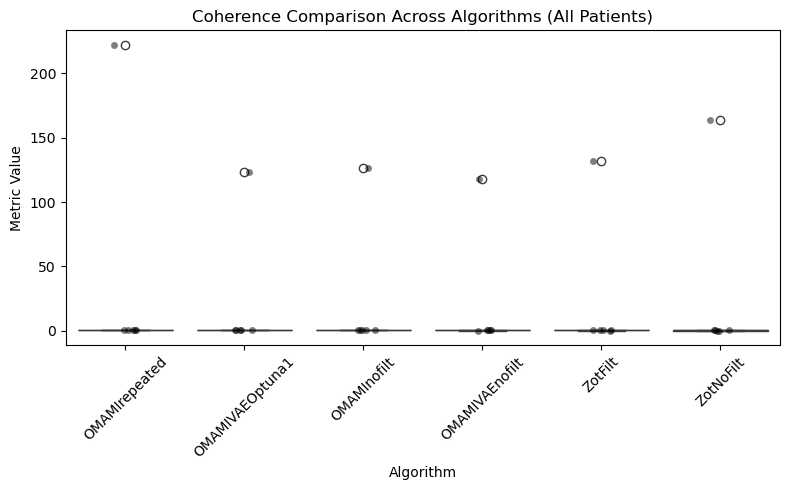

                             name                         metric_algorithm  \
3    Simulation_01_200212_001_ 10                Correlation_OMAMIrepeated   
15   Simulation_01_200212_001_ 10                       RMSE_OMAMIrepeated   
27   Simulation_01_200212_001_ 10       Peak_detector_Recall_OMAMIrepeated   
39   Simulation_01_200212_001_ 10    Peak_detector_Precision_OMAMIrepeated   
51   Simulation_01_200212_001_ 10                        DTW_OMAMIrepeated   
63   Simulation_01_200212_001_ 10                  Coherence_OMAMIrepeated   
75   Simulation_01_200212_001_ 10              Correlation_OMAMIVAEOptuna1   
87   Simulation_01_200212_001_ 10                     RMSE_OMAMIVAEOptuna1   
99   Simulation_01_200212_001_ 10     Peak_detector_Recall_OMAMIVAEOptuna1   
111  Simulation_01_200212_001_ 10  Peak_detector_Precision_OMAMIVAEOptuna1   
123  Simulation_01_200212_001_ 10                      DTW_OMAMIVAEOptuna1   
135  Simulation_01_200212_001_ 10                Coherence_OMAMI

/tmp/ipykernel_563511/4116899852.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


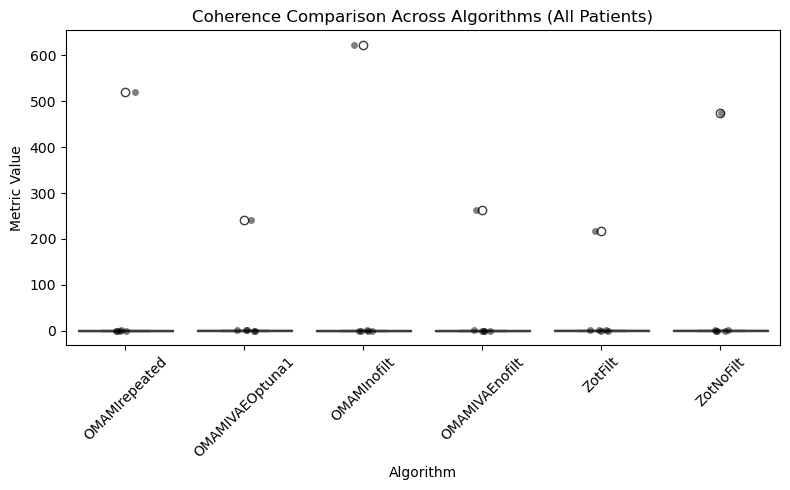

                             name                         metric_algorithm  \
4    Simulation_01_200316_001_  3                Correlation_OMAMIrepeated   
16   Simulation_01_200316_001_  3                       RMSE_OMAMIrepeated   
28   Simulation_01_200316_001_  3       Peak_detector_Recall_OMAMIrepeated   
40   Simulation_01_200316_001_  3    Peak_detector_Precision_OMAMIrepeated   
52   Simulation_01_200316_001_  3                        DTW_OMAMIrepeated   
64   Simulation_01_200316_001_  3                  Coherence_OMAMIrepeated   
76   Simulation_01_200316_001_  3              Correlation_OMAMIVAEOptuna1   
88   Simulation_01_200316_001_  3                     RMSE_OMAMIVAEOptuna1   
100  Simulation_01_200316_001_  3     Peak_detector_Recall_OMAMIVAEOptuna1   
112  Simulation_01_200316_001_  3  Peak_detector_Precision_OMAMIVAEOptuna1   
124  Simulation_01_200316_001_  3                      DTW_OMAMIVAEOptuna1   
136  Simulation_01_200316_001_  3                Coherence_OMAMI

/tmp/ipykernel_563511/4116899852.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


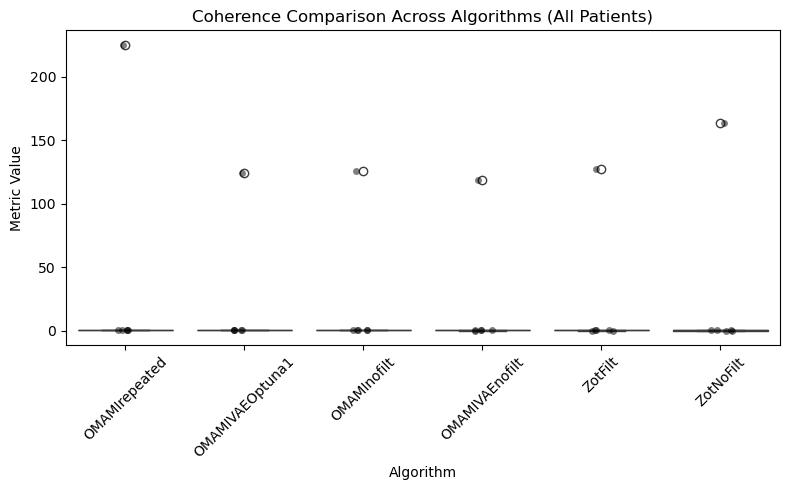

                             name                         metric_algorithm  \
5    Simulation_01_200316_001_  4                Correlation_OMAMIrepeated   
17   Simulation_01_200316_001_  4                       RMSE_OMAMIrepeated   
29   Simulation_01_200316_001_  4       Peak_detector_Recall_OMAMIrepeated   
41   Simulation_01_200316_001_  4    Peak_detector_Precision_OMAMIrepeated   
53   Simulation_01_200316_001_  4                        DTW_OMAMIrepeated   
65   Simulation_01_200316_001_  4                  Coherence_OMAMIrepeated   
77   Simulation_01_200316_001_  4              Correlation_OMAMIVAEOptuna1   
89   Simulation_01_200316_001_  4                     RMSE_OMAMIVAEOptuna1   
101  Simulation_01_200316_001_  4     Peak_detector_Recall_OMAMIVAEOptuna1   
113  Simulation_01_200316_001_  4  Peak_detector_Precision_OMAMIVAEOptuna1   
125  Simulation_01_200316_001_  4                      DTW_OMAMIVAEOptuna1   
137  Simulation_01_200316_001_  4                Coherence_OMAMI

/tmp/ipykernel_563511/4116899852.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


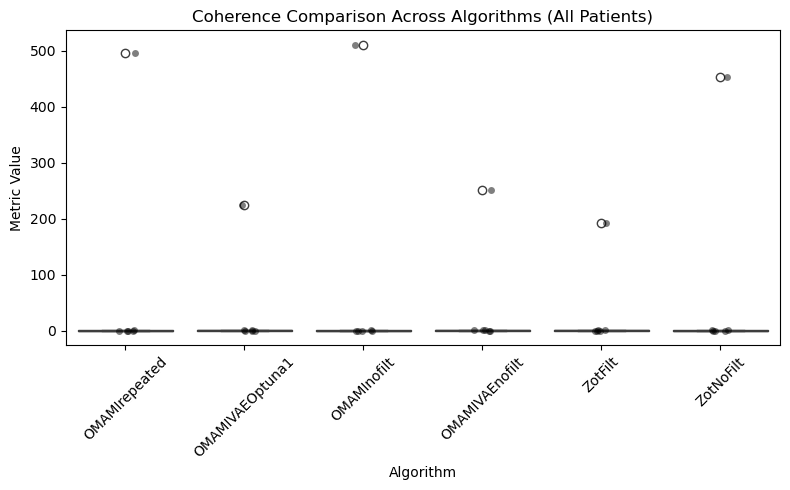

                             name                         metric_algorithm  \
6    Simulation_01_200316_001_  8                Correlation_OMAMIrepeated   
18   Simulation_01_200316_001_  8                       RMSE_OMAMIrepeated   
30   Simulation_01_200316_001_  8       Peak_detector_Recall_OMAMIrepeated   
42   Simulation_01_200316_001_  8    Peak_detector_Precision_OMAMIrepeated   
54   Simulation_01_200316_001_  8                        DTW_OMAMIrepeated   
66   Simulation_01_200316_001_  8                  Coherence_OMAMIrepeated   
78   Simulation_01_200316_001_  8              Correlation_OMAMIVAEOptuna1   
90   Simulation_01_200316_001_  8                     RMSE_OMAMIVAEOptuna1   
102  Simulation_01_200316_001_  8     Peak_detector_Recall_OMAMIVAEOptuna1   
114  Simulation_01_200316_001_  8  Peak_detector_Precision_OMAMIVAEOptuna1   
126  Simulation_01_200316_001_  8                      DTW_OMAMIVAEOptuna1   
138  Simulation_01_200316_001_  8                Coherence_OMAMI

/tmp/ipykernel_563511/4116899852.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


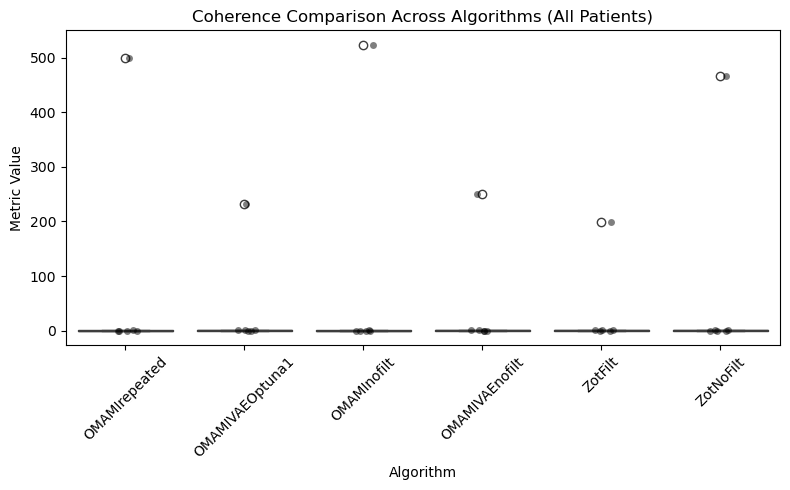

                             name                         metric_algorithm  \
7    Simulation_01_200428_001_004                Correlation_OMAMIrepeated   
19   Simulation_01_200428_001_004                       RMSE_OMAMIrepeated   
31   Simulation_01_200428_001_004       Peak_detector_Recall_OMAMIrepeated   
43   Simulation_01_200428_001_004    Peak_detector_Precision_OMAMIrepeated   
55   Simulation_01_200428_001_004                        DTW_OMAMIrepeated   
67   Simulation_01_200428_001_004                  Coherence_OMAMIrepeated   
79   Simulation_01_200428_001_004              Correlation_OMAMIVAEOptuna1   
91   Simulation_01_200428_001_004                     RMSE_OMAMIVAEOptuna1   
103  Simulation_01_200428_001_004     Peak_detector_Recall_OMAMIVAEOptuna1   
115  Simulation_01_200428_001_004  Peak_detector_Precision_OMAMIVAEOptuna1   
127  Simulation_01_200428_001_004                      DTW_OMAMIVAEOptuna1   
139  Simulation_01_200428_001_004                Coherence_OMAMI

/tmp/ipykernel_563511/4116899852.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


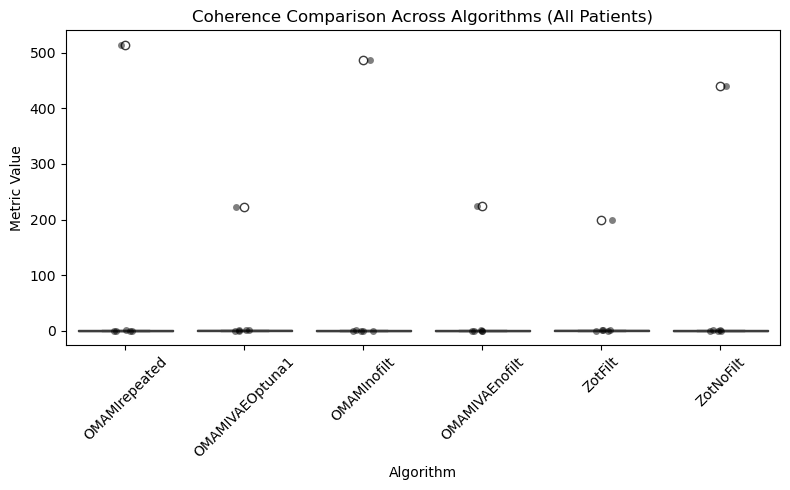

                             name                         metric_algorithm  \
8    Simulation_01_200428_001_008                Correlation_OMAMIrepeated   
20   Simulation_01_200428_001_008                       RMSE_OMAMIrepeated   
32   Simulation_01_200428_001_008       Peak_detector_Recall_OMAMIrepeated   
44   Simulation_01_200428_001_008    Peak_detector_Precision_OMAMIrepeated   
56   Simulation_01_200428_001_008                        DTW_OMAMIrepeated   
68   Simulation_01_200428_001_008                  Coherence_OMAMIrepeated   
80   Simulation_01_200428_001_008              Correlation_OMAMIVAEOptuna1   
92   Simulation_01_200428_001_008                     RMSE_OMAMIVAEOptuna1   
104  Simulation_01_200428_001_008     Peak_detector_Recall_OMAMIVAEOptuna1   
116  Simulation_01_200428_001_008  Peak_detector_Precision_OMAMIVAEOptuna1   
128  Simulation_01_200428_001_008                      DTW_OMAMIVAEOptuna1   
140  Simulation_01_200428_001_008                Coherence_OMAMI

/tmp/ipykernel_563511/4116899852.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


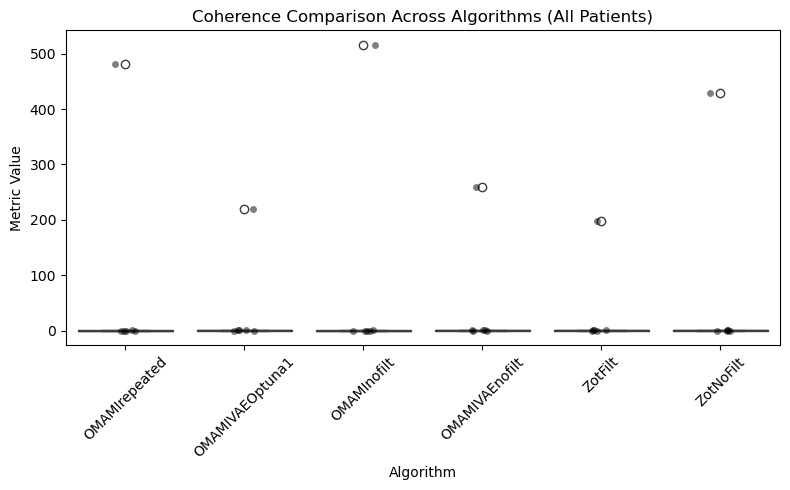

                             name                         metric_algorithm  \
9    Simulation_01_200428_001_010                Correlation_OMAMIrepeated   
21   Simulation_01_200428_001_010                       RMSE_OMAMIrepeated   
33   Simulation_01_200428_001_010       Peak_detector_Recall_OMAMIrepeated   
45   Simulation_01_200428_001_010    Peak_detector_Precision_OMAMIrepeated   
57   Simulation_01_200428_001_010                        DTW_OMAMIrepeated   
69   Simulation_01_200428_001_010                  Coherence_OMAMIrepeated   
81   Simulation_01_200428_001_010              Correlation_OMAMIVAEOptuna1   
93   Simulation_01_200428_001_010                     RMSE_OMAMIVAEOptuna1   
105  Simulation_01_200428_001_010     Peak_detector_Recall_OMAMIVAEOptuna1   
117  Simulation_01_200428_001_010  Peak_detector_Precision_OMAMIVAEOptuna1   
129  Simulation_01_200428_001_010                      DTW_OMAMIVAEOptuna1   
141  Simulation_01_200428_001_010                Coherence_OMAMI

/tmp/ipykernel_563511/4116899852.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


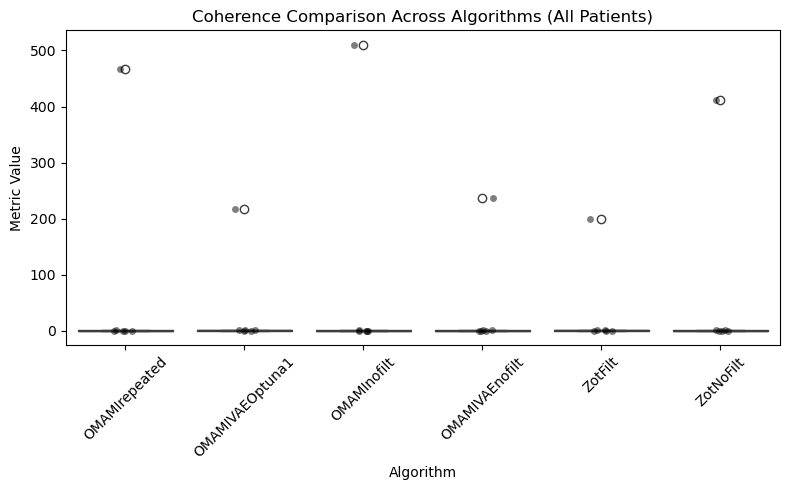

                             name                         metric_algorithm  \
10   Simulation_01_210119_001_001                Correlation_OMAMIrepeated   
22   Simulation_01_210119_001_001                       RMSE_OMAMIrepeated   
34   Simulation_01_210119_001_001       Peak_detector_Recall_OMAMIrepeated   
46   Simulation_01_210119_001_001    Peak_detector_Precision_OMAMIrepeated   
58   Simulation_01_210119_001_001                        DTW_OMAMIrepeated   
70   Simulation_01_210119_001_001                  Coherence_OMAMIrepeated   
82   Simulation_01_210119_001_001              Correlation_OMAMIVAEOptuna1   
94   Simulation_01_210119_001_001                     RMSE_OMAMIVAEOptuna1   
106  Simulation_01_210119_001_001     Peak_detector_Recall_OMAMIVAEOptuna1   
118  Simulation_01_210119_001_001  Peak_detector_Precision_OMAMIVAEOptuna1   
130  Simulation_01_210119_001_001                      DTW_OMAMIVAEOptuna1   
142  Simulation_01_210119_001_001                Coherence_OMAMI

/tmp/ipykernel_563511/4116899852.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


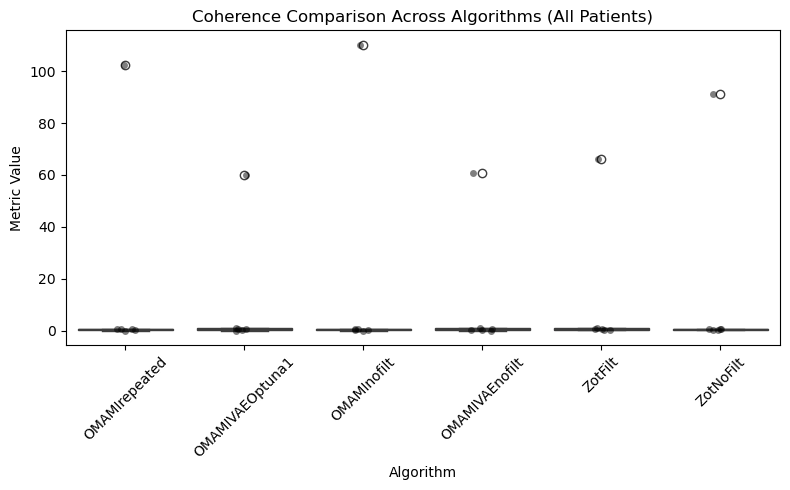

                             name                         metric_algorithm  \
11   Simulation_01_210208_001_002                Correlation_OMAMIrepeated   
23   Simulation_01_210208_001_002                       RMSE_OMAMIrepeated   
35   Simulation_01_210208_001_002       Peak_detector_Recall_OMAMIrepeated   
47   Simulation_01_210208_001_002    Peak_detector_Precision_OMAMIrepeated   
59   Simulation_01_210208_001_002                        DTW_OMAMIrepeated   
71   Simulation_01_210208_001_002                  Coherence_OMAMIrepeated   
83   Simulation_01_210208_001_002              Correlation_OMAMIVAEOptuna1   
95   Simulation_01_210208_001_002                     RMSE_OMAMIVAEOptuna1   
107  Simulation_01_210208_001_002     Peak_detector_Recall_OMAMIVAEOptuna1   
119  Simulation_01_210208_001_002  Peak_detector_Precision_OMAMIVAEOptuna1   
131  Simulation_01_210208_001_002                      DTW_OMAMIVAEOptuna1   
143  Simulation_01_210208_001_002                Coherence_OMAMI

/tmp/ipykernel_563511/4116899852.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


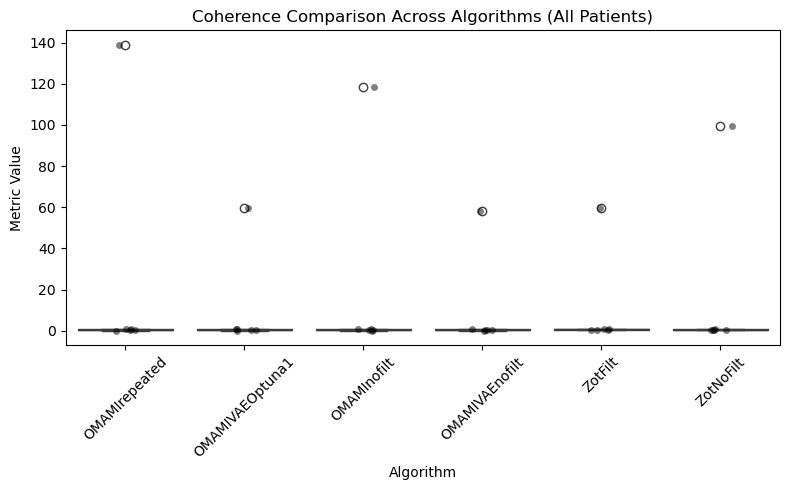

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Obtener todas las métricas únicas
name_list = long_df['name'].unique()

print(name_list)
# Generar un gráfico por cada métrica usando todos los valores de los pacientes
for name in name_list:
    plt.figure(figsize=(8, 5))  # Crear una nueva figura para cada métrica
    
    # Filtrar datos para la métrica actual (TODOS los valores de los pacientes)
    metric_data = long_df[long_df['name'] == name]

    print(metric_data)

    
    # Crear el boxplot con la distribución real de los valores
    sns.boxplot(
        data=metric_data,
        x='algorithm',
        y='value',
        palette="tab10"  # Diferenciar algoritmos con colores
    )
    
    # Agregar puntos individuales (jitter) para ver la dispersión de los pacientes
    sns.stripplot(
        data=metric_data,
        x='algorithm',
        y='value',
        color="black",
        alpha=0.5,  # Transparencia para mejor visualización
        jitter=True  # Separar puntos para que no se sobrepongan
    )
    
    # Configurar el título y etiquetas
    plt.title(f'{metric} Comparison Across Algorithms (All Patients)')
    plt.ylabel('Metric Value')
    plt.xlabel('Algorithm')
    plt.xticks(rotation=45)  # Rotar etiquetas del eje X para mejor lectura

    # Ajustar el diseño
    plt.tight_layout()
    
    # Guardar el gráfico como imagen
    plt.savefig(f'{output_path}/boxplot_{metric}.png')

    # Mostrar el gráfico
    plt.show()





In [89]:
sinusal = {
    "Simulation_01_200316_001_  7", "Simulation_01_210209_001_002",
    "Simulation_01_210205_001_002", "Simulation_01_200428_001_001",
    "Simulation_01_200316_001_ 5", "Simulation_01_200428_001_005",
    "Simulation_01_200212_001_  7", "Simulation_01_210119_001_001",
    "Simulation_01_210205_001_003", "Simulation_01_201223_001_002",
    "Simulation_01_200212_001_  1", "Simulation_01_200428_001_003",
    "Simulation_01_200316_001_  3", "Simulation_01_200316_001_  4",
    "Sinusal_150629", "RA_RAA_141216", "Simulation_01_200428_001_002",
    "Simulation_01_210210_001_001", "Simulation_01_210208_001_002",
    "Simulation_01_200212_001_  9", "Simulation_01_200316_001_  1",
    "Simulation_01_200212_001_  6", "Simulation_01_200212_001_  5",
    "Simulation_01_210209_001_003", "Simulation_01_200316_001_  9",
    "Simulation_01_210209_001_001", "Simulation_01_200428_001_006",
    "Simulation_01_200316_001_  5",
}

rotor_simple = {
    "Simulation_01_200212_001_  2", "Simulation_01_191001_001_002",
    "Simulation_01_190717_001_001", "Simulation_01_191001_001_007",
    "Simulation_01_190717_001_004", "Simulation_01_190619_001_003",
    "Simulation_01_190619_001_004", "Simulation_01_190717_001_003",
    "Simulation_01_190502_001_006", "Simulation_01_190502_001_004",
    "Simulation_01_190717_001_002", "Simulation_01_190619_001_001",
    "Simulation_01_200316_001_  8", "Simulation_01_200428_001_004",
    "Simulation_01_200212_001_  8", "Simulation_01_200212_001_10",
    "Simulation_01_191001_001_001", "Simulation_01_200428_001_007",
    "Simulation_01_200428_001_009", "Simulation_01_200428_001_010",
    "Simulation_01_200316_001_  2", "Simulation_01_200316_001_  6",
    "Simulation_01_200316_001_10", "Simulation_01_190502_001_003",
    "Simulation_01_190619_001_002", "Simulation_01_191001_001_005",
    "Simulation_01_200212_001_  4", "Simulation_01_200212_001_ 10",
    "Simulation_01_200428_001_008", "Simulation_01_190502_001_005"

}

rotor_complejo = {
    "LA_RSPV_CAF_150115", "LA_RSPV_150113'", "LA_PLAW_140612",
    "LA_LSPV_150203", "LA_LSPV_150113", "RA_RAFW_140807",
    "RA_RAA_141230", "TwoRotors_181219", "LA_PLAW_140711_arm",
    "RA_RAFW_SAF_140730", "LA_RIPV_150121", "LA_LIPV_150119"
}

# Función para clasificar cada fila
def classify_row(name):
    if name in sinusal:
        return 'Frente de Onda Sinusal'
    elif name in rotor_simple:
        return 'Rotor Simple'
    elif name in rotor_complejo:
        return 'Rotor Complejo'
    else:
        return 'Desconocido'




In [ ]:
# Crear la nueva columna de clasificación
df_DL['classification'] = df_DL['name'].apply(classify_row)

print(df_DL)

                            name  Correlation   RMSE  Peak_detector_Recall  \
2   Simulation_01_200212_001_  5        0.613  0.463                 0.311   
4   Simulation_01_200316_001_  3        0.605  0.467                 0.302   
5   Simulation_01_200316_001_  4        0.121  0.573                 0.429   
9   Simulation_01_200428_001_010        0.116  0.570                 0.443   
7   Simulation_01_200428_001_004        0.069  0.581                 0.461   
8   Simulation_01_200428_001_008        0.044  0.603                 0.500   
10  Simulation_01_210119_001_001        0.024  0.557                 0.276   
3   Simulation_01_200212_001_ 10        0.022  0.604                 0.439   
1             LA_RSPV_CAF_150115        0.008  0.636                 0.576   
6   Simulation_01_200316_001_  8        0.005  0.595                 0.403   
0             LA_PLAW_140711_arm        0.002  0.582                 0.460   
11  Simulation_01_210208_001_002       -0.007  0.606            

In [91]:

df_tik.rename(columns={'name': 'name', 'mean correlation': 'MeanCorr ZOT', 'mean RMSE': 'MeanRMSE ZOT'}, inplace=True)
df_tik=np.round(df_tik, 3)
 #Crear la nueva columna de clasificación
df_tik['classification'] = df_DL['name'].apply(classify_row)
df_tik.head(20)

,name,Correlation,RMSE,Peak_detector_Recall,Peak_detector_Precision,Peak_detector_Error,DTW,Coherence,classification
0,LA_PLAW_140711_arm,0.077,0.547,0.485,0.692,0.509,113.629,0.661,Rotor Complejo
1,LA_RSPV_CAF_150115,0.060,0.583,0.585,0.630,0.467,108.967,0.555,Rotor Complejo
2,Simulation_01_200212_001_ 5,0.030,0.554,0.181,0.721,0.601,132.138,0.906,Frente de Onda Sinusal
3,Simulation_01_200212_001_ 10,0.043,0.575,0.438,0.623,0.652,216.958,0.282,Rotor Simple
4,Simulation_01_200316_001_ 3,0.031,0.534,0.177,0.710,0.588,127.450,0.899,Frente de Onda Sinusal
5,Simulation_01_200316_001_ 4,0.074,0.552,0.436,0.567,0.497,193.188,0.299,Frente de Onda Sinusal
6,Simulation_01_200316_001_ 8,0.081,0.562,0.450,0.598,0.548,198.839,0.342,Rotor Simple
7,Simulation_01_200428_001_004,0.088,0.538,0.460,0.602,0.483,198.448,0.303,Rotor Simple
8,Simulation_01_200428_001_008,0.082,0.538,0.451,0.601,0.498,197.833,0.297,Rotor Simple
9,Simulation_01_200428_001_010,0.083,0.529,0.436,0.595,0.551,198.968,0.259,Rotor Simple


In [ ]:


# Suponiendo que el DataFrame se llama df
# Calcular las medias por métrica
metric_means = df_tik.drop(columns=['name']).mean().reset_index()
metric_means.columns = ['metric', 'mean']

# Mostrar las medias calculadas
print("Medias por métrica:")
print(metric_means)

# Crear un gráfico de barras para las medias por métrica
plt.figure(figsize=(10, 6))
sns.barplot(data=metric_means, x='metric', y='mean', palette='viridis')
plt.title('Average Value by Metric')
plt.xlabel('Metric')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar el gráfico
plt.show()


TypeError: Could not convert ['Rotor ComplejoRotor ComplejoFrente de Onda SinusalRotor SimpleFrente de Onda SinusalFrente de Onda SinusalRotor SimpleRotor SimpleRotor SimpleRotor SimpleFrente de Onda SinusalFrente de Onda Sinusal'] to numeric

In [11]:
print('ZOT --> Mean corr: ', np.round(df_tik['MeanCorr ZOT'].mean(), 3), '+-', np.round(df_tik['MeanCorr ZOT'].std(), 3) )
print('ZOT --> Mean RMSE: ', np.round(df_tik['MeanRMSE ZOT'].mean(), 3), '+-', np.round(df_tik['MeanRMSE ZOT'].std(), 3) )
print('DL --> Mean corr: ', np.round(df_DL['MeanCorr DL'].mean(), 3), '+-', np.round(df_DL['MeanCorr DL'].std(), 3) )
print('DL --> Mean RMSE: ', np.round(df_DL['MeanRMSE DL'].mean(), 3), '+-', np.round(df_DL['MeanRMSE DL'].std(), 3) )


ZOT --> Mean corr:  0.095 +- 0.073
ZOT --> Mean RMSE:  0.555 +- 0.018
DL --> Mean corr:  0.135 +- 0.225
DL --> Mean RMSE:  0.57 +- 0.053


In [12]:
df_merged = pd.merge(df_DL,df_tik, on='name')
df_merged.head(20)


,name,MeanCorr DL,MeanRMSE DL,classification_x,MeanCorr ZOT,MeanRMSE ZOT,classification_y
0,Simulation_01_200212_001_ 5,0.613,0.463,Frente de Onda Sinusal,0.030,0.554,Frente de Onda Sinusal
1,Simulation_01_200316_001_ 3,0.605,0.467,Frente de Onda Sinusal,0.031,0.534,Frente de Onda Sinusal
2,Simulation_01_200316_001_ 4,0.122,0.567,Frente de Onda Sinusal,0.074,0.552,Frente de Onda Sinusal
3,Simulation_01_200428_001_010,0.116,0.570,Rotor Simple,0.083,0.529,Rotor Simple
4,Simulation_01_200428_001_004,0.068,0.580,Rotor Simple,0.088,0.538,Rotor Simple
5,Simulation_01_200428_001_008,0.045,0.603,Rotor Simple,0.082,0.538,Rotor Simple
6,Simulation_01_210119_001_001,0.028,0.562,Frente de Onda Sinusal,0.225,0.565,Frente de Onda Sinusal
7,Simulation_01_200212_001_ 10,0.021,0.605,Rotor Simple,0.043,0.575,Rotor Simple
8,LA_RSPV_CAF_150115,0.008,0.636,Rotor Complejo,0.060,0.583,Rotor Complejo
9,Simulation_01_200316_001_ 8,0.004,0.596,Rotor Simple,0.081,0.562,Rotor Simple


In [13]:
df_merged_sorted_by_zot = df_merged.sort_values(by='MeanCorr ZOT', ascending=False)
df_merged_sorted_by_zot.head(20)

,name,MeanCorr DL,MeanRMSE DL,classification_x,MeanCorr ZOT,MeanRMSE ZOT,classification_y
11,Simulation_01_210208_001_002,-0.007,0.606,Frente de Onda Sinusal,0.264,0.579,Frente de Onda Sinusal
6,Simulation_01_210119_001_001,0.028,0.562,Frente de Onda Sinusal,0.225,0.565,Frente de Onda Sinusal
4,Simulation_01_200428_001_004,0.068,0.580,Rotor Simple,0.088,0.538,Rotor Simple
3,Simulation_01_200428_001_010,0.116,0.570,Rotor Simple,0.083,0.529,Rotor Simple
5,Simulation_01_200428_001_008,0.045,0.603,Rotor Simple,0.082,0.538,Rotor Simple
9,Simulation_01_200316_001_ 8,0.004,0.596,Rotor Simple,0.081,0.562,Rotor Simple
10,LA_PLAW_140711_arm,0.002,0.583,Rotor Complejo,0.077,0.547,Rotor Complejo
2,Simulation_01_200316_001_ 4,0.122,0.567,Frente de Onda Sinusal,0.074,0.552,Frente de Onda Sinusal
8,LA_RSPV_CAF_150115,0.008,0.636,Rotor Complejo,0.060,0.583,Rotor Complejo
7,Simulation_01_200212_001_ 10,0.021,0.605,Rotor Simple,0.043,0.575,Rotor Simple


/tmp/ipykernel_339160/1151243277.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([numerical_columns[col] for col in rmse_columns], labels=rmse_columns)
/tmp/ipykernel_339160/1151243277.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([numerical_columns[col] for col in corr_columns], labels=corr_columns)


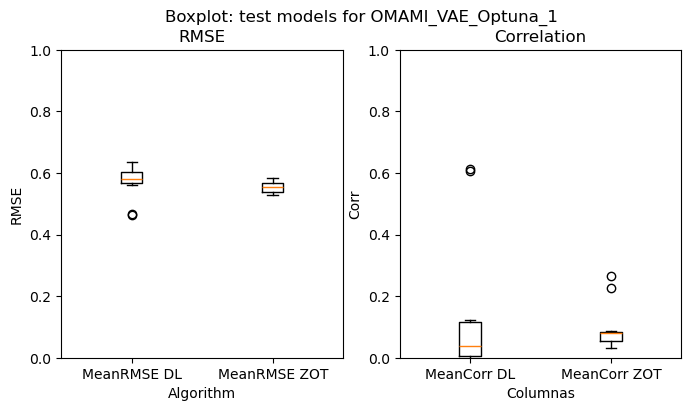

In [14]:
# Crear el boxplot solo con las columnas numéricas
numerical_columns = df_merged.select_dtypes(include="number")  # Seleccionar solo columnas numéricas
# Filtrar las columnas que contienen "RMSE" en su nombre
rmse_columns = [col for col in numerical_columns.columns if "RMSE" in col]
corr_columns = [col for col in numerical_columns.columns if "Corr" in col]


plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.boxplot([numerical_columns[col] for col in rmse_columns], labels=rmse_columns)
plt.title("RMSE")
plt.ylabel("RMSE")
plt.xlabel("Algorithm")
plt.ylim([0,1])
plt.subplot(1,2,2)
plt.boxplot([numerical_columns[col] for col in corr_columns], labels=corr_columns)
plt.title("Correlation")
plt.ylabel("Corr")
plt.xlabel("Columnas")
plt.ylim([0,1])
plt.suptitle(f"Boxplot: test models for {algorithm_ID}")
plt.show()


In [15]:
print('DL agregado --> Mean corr: ', np.round(df_DL['MeanCorr DL'].mean(), 3), '+-', np.round(df_DL['MeanCorr DL'].std(), 3) )
print('DL agregado --> Mean RMSE: ', np.round(df_DL['MeanRMSE DL'].mean(), 3), '+-', np.round(df_DL['MeanRMSE DL'].std(), 3) )

print('ZOT agregado--> Mean corr: ', np.round(df_tik['MeanCorr ZOT'].mean(), 3), '+-', np.round(df_tik['MeanCorr ZOT'].std(), 3) )
print('ZOT agregado --> Mean RMSE: ', np.round(df_tik['MeanRMSE ZOT'].mean(), 3), '+-', np.round(df_tik['MeanRMSE ZOT'].std(), 3) )


DL agregado --> Mean corr:  0.135 +- 0.225
DL agregado --> Mean RMSE:  0.57 +- 0.053
ZOT agregado--> Mean corr:  0.095 +- 0.073
ZOT agregado --> Mean RMSE:  0.555 +- 0.018


In [16]:
print(algorithm_ID)

OMAMI_VAE_Optuna_1
